# EDA completo — Bronze del Observatorio Energético

**Catálogo:** `observatorio_dev`  
**Esquema:** `bronze`  
**Fuentes:** agentes, demanda, disponibilidad, embalses, generación, niveles de embalses, plantas, relaciones planta–reservorio y precio de bolsa.  
**Evidencia revisada:** ejecución conservada en el notebook, con corte de análisis al 23 de julio de 2026.

> Este notebook diagnostica la capa Bronze sin modificarla. Las conclusiones siguientes se basan exclusivamente en las salidas ejecutadas.

## TL;DR

- **Estado general: apto condicionado.** Las nueve tablas reúnen **24.590.150 registros** y presentan una base técnica sólida: no se detectaron valores no convertibles, dominios inesperados, duplicados exactos, duplicados de llave dentro de la misma versión ni conflictos de valor dentro de una misma versión.
- **El principal riesgo es la dimensión de plantas.** No tienen correspondencia en `plantas` **161 de 612 códigos de generación (26,31 %)** y **168 de 620 códigos de disponibilidad (27,10 %)**. Un `INNER JOIN` eliminaría silenciosamente una parte material de los recursos.
- **Bronze no puede sumarse directamente.** Las versiones `TX` son revisiones legítimas, no duplicados de ingestión. Después de aplicar la prioridad configurada `TXF > TXR > TX3 > TX2 > TX1`, los hechos se reducen a su grano canónico: 437.856 filas de demanda, 2.609.784 de disponibilidad, 2.553.576 de generación, 4.200 de niveles y 14.400 de precio.
- **La cobertura horaria es fuerte**, pero las fuentes no tienen el mismo corte. Generación termina el 13 de julio, demanda y disponibilidad el 17, y precio y niveles el 19. Para comparar el sistema, el último corte común válido es **2026-07-13**.
- **La geografía de embalses está incompleta:** 13 de 32 embalses (40,63 %) no tienen latitud ni longitud. Las 19 coordenadas presentes son válidas y están dentro de la caja geográfica aproximada de Colombia.
- **Decisión:** Silver puede construirse o reforzarse con selección canónica, dimensión de plantas conformada, uniones temporales y controles de frescura. Gold y el dashboard no deben consumir Bronze de forma directa.

## 1. Contexto, alcance y supuestos

### Objetivo

Evaluar si los datos crudos son suficientemente completos, válidos, trazables y coherentes para alimentar Silver, Gold y el dashboard del MVP.

### Qué se revisa

1. Inventario, esquema y trazabilidad de carga.
2. Completitud, cardinalidad y conversiones de tipo.
3. Duplicados exactos, duplicados de llave y revisiones entre versiones.
4. Cobertura temporal, continuidad horaria/diaria y frescura.
5. Dominios, unidades, duraciones, mercados y versiones.
6. Rangos, ceros, negativos y valores atípicos.
7. Integridad entre plantas, agentes, embalses y hechos.
8. Coherencia entre generación, disponibilidad, capacidad, demanda y precios.
9. Candidatos de hallazgos priorizados para redactar las conclusiones.

### Supuestos importantes

- Bronze conserva el dato recibido y, por diseño, puede contener reingestas y distintas versiones.
- `TX1`, `TX2`, `TX3`, `TXR` y `TXF` se analizan por separado. Para comparaciones canónicas se usa una prioridad **configurable**: `TXF > TXR > TX3 > TX2 > TX1`.
- Los campos `valor`, `cap_efectiva_neta`, `latitud` y `longitud` se validan con `try_cast`; el notebook no cambia su tipo en Bronze.
- En datos `PT1H`, 24 periodos por entidad-día representan cobertura completa. Los días extremos del rango pueden estar parcialmente cargados y deben interpretarse con cautela.
- `plantas` y `agentes` se consideran snapshots, no series obligatoriamente publicadas todos los días.
- La comparación `kWh` de una hora frente a `kW` de capacidad es numéricamente válida para ese intervalo de una hora.

In [0]:
from pyspark.sql import functions as F, Window
from pyspark.sql.types import StringType
from functools import reduce
from datetime import date

CATALOG = "observatorio_dev"
SCHEMA = "bronze"

# Mantener True para el EDA completo. Cambiar a False solo para una prueba rápida.
EJECUTAR_PERFIL_PESADO = True
MAX_FILAS_MUESTRA = 100
TOLERANCIA_OPERATIVA = 1.05

TABLAS = [
    "agentes",
    "demanda_real",
    "disponibilidad_plantas",
    "embalses",
    "generacion_real",
    "niveles_embalses",
    "plantas",
    "plantas_reservorios",
    "precio_bolsa",
]

AUDITORIA = {
    "id", "source_file_name", "source_file_path",
    "ingestion_timestamp", "load_date"
}

VERSION_PRIORITY = {
    "TX1": 10,
    "TX2": 20,
    "TX3": 30,
    "TXR": 40,
    "TXF": 50,
}

DOMINIOS_ESPERADOS = {
    "agentes": {
        "codigo_duracion": {"P1D"},
    },
    "demanda_real": {
        "codigo_duracion": {"PT1H"},
        "codigo_variable": {"DdaReal"},
        "unidad_medida": {"kWh"},
        "version": set(VERSION_PRIORITY),
        "tipo_mercado": {"Regulado", "No Regulado"},
    },
    "disponibilidad_plantas": {
        "codigo_duracion": {"PT1H"},
        "codigo_variable": {"DispReal"},
        "unidad_medida": {"kWh"},
        "version": set(VERSION_PRIORITY),
    },
    "generacion_real": {
        "codigo_duracion": {"PT1H"},
        "codigo_variable": {"GReal"},
        "unidad_medida": {"kWh"},
        "version": set(VERSION_PRIORITY),
    },
    "niveles_embalses": {
        "codigo_duracion": {"P1D"},
        "codigo_variable": {"NEM"},
        "unidad_medida": {"kWh"},
        "version": set(VERSION_PRIORITY),
    },
    "plantas": {
        "codigo_duracion": {"P1D"},
    },
    "precio_bolsa": {
        "codigo_duracion": {"PT1H"},
        "codigo_variable": {"PB_Nal", "PB_Int", "PB_Tie"},
        "unidad_medida": {"COP/kWh"},
        "version": set(VERSION_PRIORITY),
    },
}

CONFIG = {
    "agentes": {
        "fecha": "fecha",
        "frecuencia": "snapshot_diario",
        "entidad": ["codigo_sic_agente", "actividad_agente"],
        "llave_version": ["fecha", "codigo_sic_agente", "actividad_agente"],
        "llave_canonica": ["fecha", "codigo_sic_agente", "actividad_agente"],
        "numericas": [],
        "categoricas": ["codigo_duracion", "actividad_agente"],
    },
    "demanda_real": {
        "fecha": "fecha_hora",
        "frecuencia": "horaria",
        "entidad": ["codigo_sic_agente", "tipo_mercado", "codigo_variable"],
        "llave_version": [
            "fecha_hora", "codigo_sic_agente", "tipo_mercado",
            "codigo_variable", "codigo_duracion", "version"
        ],
        "llave_canonica": [
            "fecha_hora", "codigo_sic_agente", "tipo_mercado",
            "codigo_variable", "codigo_duracion"
        ],
        "numericas": ["valor"],
        "categoricas": [
            "codigo_duracion", "codigo_variable", "tipo_mercado",
            "unidad_medida", "version"
        ],
    },
    "disponibilidad_plantas": {
        "fecha": "fecha_hora",
        "frecuencia": "horaria",
        "entidad": ["codigo_planta", "codigo_variable"],
        "llave_version": [
            "fecha_hora", "codigo_planta", "codigo_variable",
            "codigo_duracion", "version"
        ],
        "llave_canonica": [
            "fecha_hora", "codigo_planta", "codigo_variable",
            "codigo_duracion"
        ],
        "numericas": ["valor"],
        "categoricas": [
            "codigo_duracion", "codigo_variable", "unidad_medida", "version"
        ],
    },
    "embalses": {
        "fecha": None,
        "frecuencia": "maestro",
        "entidad": ["codigo_embalse"],
        "llave_version": ["codigo_embalse"],
        "llave_canonica": ["codigo_embalse"],
        "numericas": ["latitud", "longitud"],
        "categoricas": [],
    },
    "generacion_real": {
        "fecha": "fecha_hora",
        "frecuencia": "horaria",
        "entidad": ["codigo_planta", "codigo_variable"],
        "llave_version": [
            "fecha_hora", "codigo_planta", "codigo_sic_agente",
            "codigo_variable", "codigo_duracion", "version"
        ],
        "llave_canonica": [
            "fecha_hora", "codigo_planta", "codigo_sic_agente",
            "codigo_variable", "codigo_duracion"
        ],
        "numericas": ["valor"],
        "categoricas": [
            "codigo_duracion", "codigo_variable", "unidad_medida", "version"
        ],
    },
    "niveles_embalses": {
        "fecha": "fecha_inicio",
        "frecuencia": "diaria",
        "entidad": ["codigo_planta", "codigo_variable"],
        "llave_version": [
            "fecha_inicio", "codigo_planta", "codigo_variable",
            "codigo_duracion", "version"
        ],
        "llave_canonica": [
            "fecha_inicio", "codigo_planta", "codigo_variable",
            "codigo_duracion"
        ],
        "numericas": ["valor"],
        "categoricas": [
            "codigo_duracion", "codigo_variable", "unidad_medida", "version"
        ],
    },
    "plantas": {
        "fecha": "fecha",
        "frecuencia": "snapshot_diario",
        "entidad": ["codigo_planta"],
        "llave_version": ["fecha", "codigo_planta"],
        "llave_canonica": ["fecha", "codigo_planta"],
        "numericas": ["cap_efectiva_neta"],
        "fechas_adicionales": ["fpo"],
        "categoricas": [
            "codigo_duracion", "tipo_despacho_recurso",
            "tipo_clasificacion", "tipo_generacion",
            "codigo_sub_area_operativa", "codigo_area_operativa"
        ],
    },
    "plantas_reservorios": {
        "fecha": None,
        "frecuencia": "maestro",
        "entidad": ["nombre_planta", "nombre_reservorio"],
        "llave_version": ["nombre_planta", "nombre_reservorio"],
        "llave_canonica": ["nombre_planta", "nombre_reservorio"],
        "numericas": [],
        "categoricas": ["region"],
    },
    "precio_bolsa": {
        "fecha": "fecha_hora",
        "frecuencia": "horaria",
        "entidad": ["codigo_variable"],
        "llave_version": [
            "fecha_hora", "codigo_variable", "codigo_duracion", "version"
        ],
        "llave_canonica": [
            "fecha_hora", "codigo_variable", "codigo_duracion"
        ],
        "numericas": ["valor"],
        "categoricas": [
            "codigo_duracion", "codigo_variable", "unidad_medida", "version"
        ],
    },
}

def nombre_tabla(tabla):
    return f"{CATALOG}.{SCHEMA}.{tabla}"

def fecha_evento(tabla):
    return F.to_timestamp(F.col(CONFIG[tabla]["fecha"]))

def normalizar_texto(columna):
    texto = F.upper(F.trim(columna))
    texto = F.regexp_replace(texto, r"\s+", " ")
    return F.translate(
        texto,
        "ÁÉÍÓÚÜÑÀÈÌÒÙÂÊÎÔÛÄËÏÖÜ",
        "AEIOUUNAEIOUAEIOUAEIOU"
    )

def prioridad_version():
    elementos = []
    for version, prioridad in VERSION_PRIORITY.items():
        elementos.extend([F.lit(version), F.lit(prioridad)])
    mapa = F.create_map(*elementos)
    return F.coalesce(
        F.element_at(mapa, F.upper(F.trim(F.col("version")))),
        F.lit(0)
    )

def seleccionar_version_canonica(tabla):
    df = spark.table(nombre_tabla(tabla))
    llaves = CONFIG[tabla]["llave_canonica"]
    if "version" not in df.columns:
        return df
    orden = [
        prioridad_version().desc(),
        F.col("ingestion_timestamp").desc_nulls_last(),
        F.col("load_date").desc_nulls_last(),
    ]
    if "id" in df.columns:
        orden.append(F.col("id").desc_nulls_last())
    ventana = Window.partitionBy(*llaves).orderBy(*orden)
    return (
        df.withColumn("_rn_canonica", F.row_number().over(ventana))
          .filter(F.col("_rn_canonica") == 1)
          .drop("_rn_canonica")
    )

print(f"Configuración cargada para {len(TABLAS)} tablas.")

Configuración cargada para 9 tablas.


## 2. Validación de entradas y diccionario de datos

In [0]:
tablas_disponibles = {
    fila.tableName
    for fila in spark.sql(f"SHOW TABLES IN {CATALOG}.{SCHEMA}").collect()
}

faltantes = sorted(set(TABLAS) - tablas_disponibles)
extras = sorted(tablas_disponibles - set(TABLAS))

assert not faltantes, f"Faltan tablas requeridas: {faltantes}"

print(f"Tablas requeridas encontradas: {len(TABLAS)}")
print(f"Tablas adicionales no incluidas: {extras or 'ninguna'}")

errores_config = []
for tabla in TABLAS:
    columnas = set(spark.table(nombre_tabla(tabla)).columns)
    requeridas = set(CONFIG[tabla]["llave_version"])
    requeridas.update(CONFIG[tabla].get("numericas", []))
    requeridas.update(CONFIG[tabla].get("categoricas", []))
    if CONFIG[tabla]["fecha"]:
        requeridas.add(CONFIG[tabla]["fecha"])
    ausentes = sorted(requeridas - columnas)
    if ausentes:
        errores_config.append((tabla, ausentes))

assert not errores_config, f"Columnas configuradas ausentes: {errores_config}"
print("La configuración coincide con los esquemas actuales.")

Tablas requeridas encontradas: 9
Tablas adicionales no incluidas: ninguna
La configuración coincide con los esquemas actuales.


In [0]:
diccionario_filas = []
for tabla in TABLAS:
    for campo in spark.table(nombre_tabla(tabla)).schema.fields:
        diccionario_filas.append({
            "tabla": tabla,
            "columna": campo.name,
            "tipo_bronze": campo.dataType.simpleString(),
            "nullable": campo.nullable,
            "rol": (
                "auditoría" if campo.name in AUDITORIA
                else "llave con versión" if campo.name in CONFIG[tabla]["llave_version"]
                else "medida a validar" if campo.name in CONFIG[tabla].get("numericas", [])
                else "atributo"
            )
        })

diccionario_df = spark.createDataFrame(diccionario_filas)
display(diccionario_df.orderBy("tabla", "columna"))

columna,nullable,rol,tabla,tipo_bronze
actividad_agente,true,llave con versión,agentes,string
codigo_duracion,true,atributo,agentes,string
codigo_sic_agente,true,llave con versión,agentes,string
fecha,true,llave con versión,agentes,string
ingestion_timestamp,true,auditoría,agentes,timestamp
load_date,true,auditoría,agentes,date
nombre_agente,true,atributo,agentes,string
source_file_name,true,auditoría,agentes,string
source_file_path,true,auditoría,agentes,string
codigo_duracion,true,llave con versión,demanda_real,string


In [0]:
for tabla in TABLAS:
    print(f"Muestra — {tabla}")
    display(spark.table(nombre_tabla(tabla)).limit(5))

Muestra — agentes


fecha,codigo_duracion,codigo_sic_agente,nombre_agente,actividad_agente,source_file_name,source_file_path,ingestion_timestamp,load_date
2026-07-12,P1D,RTQG,RUITOQUE S.A. E.S.P.,Generador,agentes.json,/Volumes/observatorio_dev/landing/raw_files/agentes.json,2026-07-17T16:42:29.385Z,2026-07-17
2026-07-12,P1D,EEAD,ENERGÍA ELÉCTRICA DE LA COSTA ATLÁNTICA S.A. E.S.P,Distribuidor,agentes.json,/Volumes/observatorio_dev/landing/raw_files/agentes.json,2026-07-17T16:42:29.385Z,2026-07-17
2026-07-12,P1D,TCBC,TERMO CARIBE S.A.S. E.S.P.,Comercializador,agentes.json,/Volumes/observatorio_dev/landing/raw_files/agentes.json,2026-07-17T16:42:29.385Z,2026-07-17
2026-07-12,P1D,PCEG,PROMOENERCOL COMERCIALIZADORA DE ENERGÍA S.A.S E.S.P,Generador,agentes.json,/Volumes/observatorio_dev/landing/raw_files/agentes.json,2026-07-17T16:42:29.385Z,2026-07-17
2026-07-12,P1D,CERG,CEE ENERGY SAS ESP,Generador,agentes.json,/Volumes/observatorio_dev/landing/raw_files/agentes.json,2026-07-17T16:42:29.385Z,2026-07-17


Muestra — demanda_real


codigo_duracion,codigo_sic_agente,codigo_variable,fecha_hora,tipo_mercado,unidad_medida,valor,version,source_file_name,source_file_path,ingestion_timestamp,load_date
PT1H,EMSC,DdaReal,2026-01-16T23:00:00,Regulado,kWh,119019.3,TX3,demanda_real.json,/Volumes/observatorio_dev/landing/raw_files/demanda_real.json,2026-07-02T22:36:06.117Z,2026-07-02
PT1H,EMSC,DdaReal,2026-01-16T22:00:00,Regulado,kWh,130259.63,TX3,demanda_real.json,/Volumes/observatorio_dev/landing/raw_files/demanda_real.json,2026-07-02T22:36:06.117Z,2026-07-02
PT1H,EMSC,DdaReal,2026-01-16T21:00:00,Regulado,kWh,141033.94,TX3,demanda_real.json,/Volumes/observatorio_dev/landing/raw_files/demanda_real.json,2026-07-02T22:36:06.117Z,2026-07-02
PT1H,EMSC,DdaReal,2026-01-16T20:00:00,Regulado,kWh,149837.97,TX3,demanda_real.json,/Volumes/observatorio_dev/landing/raw_files/demanda_real.json,2026-07-02T22:36:06.117Z,2026-07-02
PT1H,EMSC,DdaReal,2026-01-16T19:00:00,Regulado,kWh,158768.64,TX3,demanda_real.json,/Volumes/observatorio_dev/landing/raw_files/demanda_real.json,2026-07-02T22:36:06.117Z,2026-07-02


Muestra — disponibilidad_plantas


...

id,fecha,codigo_duracion,codigo_planta,nombre_planta,codigo_sic_agente,cap_efectiva_neta,fpo,codigo_sub_area_operativa,codigo_area_operativa,tipo_despacho_recurso,tipo_clasificacion,tipo_generacion,source_file_name,source_file_path,ingestion_timestamp,load_date
2,2026-06-03,P1D,5NK4,AGPE ZULMA CRISTINA USTARIZ MORA,NEUC,10.0,2026-03-19,Are0025,Are0127,No Despachado Centralmente,AUTOGENERADOR PEQUEÑA ESCALA,Solar,plantas.json,dbfs:/Volumes/observatorio_dev/landing/raw_files/plantas.json,2026-07-05T21:38:58.962Z,2026-07-05
4,2026-06-03,P1D,5FOQ,AGPE 309 ARA SANTA MARTA GAIRA,NEUC,50.0,2025-11-14,Are0025,Are0127,No Despachado Centralmente,AUTOGENERADOR PEQUEÑA ESCALA,Solar,plantas.json,dbfs:/Volumes/observatorio_dev/landing/raw_files/plantas.json,2026-07-05T21:38:58.962Z,2026-07-05
6,2026-06-03,P1D,3J5J,AGPE SUBASTAR MONTERIA,SCEC,45.0,2023-12-01,Are0021,Are0127,No Despachado Centralmente,AUTOGENERADOR PEQUEÑA ESCALA,Solar,plantas.json,dbfs:/Volumes/observatorio_dev/landing/raw_files/plantas.json,2026-07-05T21:38:58.962Z,2026-07-05
8,2026-06-03,P1D,5P1J,AGPE PRODE1,ETTC,120.0,2026-04-16,Are0017,Are0056,No Despachado Centralmente,AUTOGENERADOR PEQUEÑA ESCALA,Solar,plantas.json,dbfs:/Volumes/observatorio_dev/landing/raw_files/plantas.json,2026-07-05T21:38:58.962Z,2026-07-05
10,2026-06-03,P1D,ALBG,ALBAN,EPSG,427000.0,2000-12-15,Are0032,Are0128,Despachado Centralmente,GENERADOR,Hidraulica,plantas.json,dbfs:/Volumes/observatorio_dev/landing/raw_files/plantas.json,2026-07-05T21:38:58.962Z,2026-07-05


Muestra — plantas_reservorios


id,region,nombre_planta,nombre_reservorio,source_file_name,source_file_path,ingestion_timestamp,load_date
1,Antioquia,Miel I,Amani,plantas-embalses.json,dbfs:/Volumes/observatorio_dev/landing/raw_files/plantas-embalses.json,2026-07-05T19:29:31.702Z,2026-07-05
2,Antioquia,Guatrón,Miraflores,plantas-embalses.json,dbfs:/Volumes/observatorio_dev/landing/raw_files/plantas-embalses.json,2026-07-05T19:29:31.702Z,2026-07-05
3,Antioquia,Guatapé,Peñol,plantas-embalses.json,dbfs:/Volumes/observatorio_dev/landing/raw_files/plantas-embalses.json,2026-07-05T19:29:31.702Z,2026-07-05
4,Antioquia,Playas,Playas,plantas-embalses.json,dbfs:/Volumes/observatorio_dev/landing/raw_files/plantas-embalses.json,2026-07-05T19:29:31.702Z,2026-07-05
5,Antioquia,Porce II,Porce II,plantas-embalses.json,dbfs:/Volumes/observatorio_dev/landing/raw_files/plantas-embalses.json,2026-07-05T19:29:31.702Z,2026-07-05


Muestra — precio_bolsa


id,codigo_variable,fecha_hora,codigo_duracion,unidad_medida,version,valor,source_file_name,source_file_path,ingestion_timestamp,load_date
60769,PB_Nal,2026-07-19T09:00:00,PT1H,COP/kWh,TX1,656.6319,precio_bolsa.json,/Volumes/observatorio_dev/landing/raw_files/precio_bolsa.json,2026-07-22T13:06:05.102Z,2026-07-22
60770,PB_Int,2026-07-19T04:00:00,PT1H,COP/kWh,TX1,732.029,precio_bolsa.json,/Volumes/observatorio_dev/landing/raw_files/precio_bolsa.json,2026-07-22T13:06:05.102Z,2026-07-22
60771,PB_Tie,2026-07-19T16:00:00,PT1H,COP/kWh,TX1,950.0,precio_bolsa.json,/Volumes/observatorio_dev/landing/raw_files/precio_bolsa.json,2026-07-22T13:06:05.102Z,2026-07-22
60772,PB_Tie,2026-07-19T23:00:00,PT1H,COP/kWh,TX1,940.0,precio_bolsa.json,/Volumes/observatorio_dev/landing/raw_files/precio_bolsa.json,2026-07-22T13:06:05.102Z,2026-07-22
60773,PB_Int,2026-07-19T09:00:00,PT1H,COP/kWh,TX1,656.0,precio_bolsa.json,/Volumes/observatorio_dev/landing/raw_files/precio_bolsa.json,2026-07-22T13:06:05.102Z,2026-07-22


## 3. Inventario, volumen, cobertura y trazabilidad

In [0]:
inventario_filas = []
conteos_tabla = {}

for tabla in TABLAS:
    df = spark.table(nombre_tabla(tabla))
    total = df.count()
    conteos_tabla[tabla] = total

    detalle = spark.sql(f"DESCRIBE DETAIL {nombre_tabla(tabla)}").first().asDict()
    fila = {
        "tabla": tabla,
        "registros": total,
        "columnas": len(df.columns),
        "archivos_delta": detalle.get("numFiles"),
        "tamano_bytes": detalle.get("sizeInBytes"),
        "ultima_modificacion_delta": detalle.get("lastModified"),
        "primera_carga": None,
        "ultima_carga": None,
        "primera_ingesta": None,
        "ultima_ingesta": None,
        "primera_fecha_evento": None,
        "ultima_fecha_evento": None,
    }

    auditoria = df.agg(
        F.min("load_date").alias("primera_carga"),
        F.max("load_date").alias("ultima_carga"),
        F.min("ingestion_timestamp").alias("primera_ingesta"),
        F.max("ingestion_timestamp").alias("ultima_ingesta"),
    ).first().asDict()
    fila.update(auditoria)

    if CONFIG[tabla]["fecha"]:
        rango = (
            df.select(fecha_evento(tabla).alias("_fecha_evento"))
              .agg(
                  F.min("_fecha_evento").alias("primera_fecha_evento"),
                  F.max("_fecha_evento").alias("ultima_fecha_evento"),
              )
              .first()
              .asDict()
        )
        fila.update(rango)

    inventario_filas.append(fila)

inventario_df = spark.createDataFrame(inventario_filas)
display(inventario_df.orderBy(F.desc("registros")))

archivos_delta,columnas,primera_carga,primera_fecha_evento,primera_ingesta,registros,tabla,tamano_bytes,ultima_carga,ultima_fecha_evento,ultima_ingesta,ultima_modificacion_delta
4,13,2026-07-16,2026-01-01T00:00:00.000Z,2026-07-16T21:43:21.282Z,11716152,generacion_real,69077144,2026-07-16,2026-07-13T23:00:00.000Z,2026-07-16T21:43:21.282Z,2026-07-23T04:38:04.000Z
4,12,2026-07-16,2026-01-01T00:00:00.000Z,2026-07-16T23:17:51.420Z,11028576,disponibilidad_plantas,54698258,2026-07-21,2026-07-17T23:00:00.000Z,2026-07-21T19:12:15.241Z,2026-07-23T04:37:31.000Z
8,12,2026-07-02,2026-01-01T00:00:00.000Z,2026-07-02T22:36:06.117Z,1423752,demanda_real,5191126,2026-07-22,2026-07-17T23:00:00.000Z,2026-07-22T13:04:38.228Z,2026-07-23T04:37:09.000Z
8,17,2026-07-05,2026-01-01T00:00:00.000Z,2026-07-05T21:38:58.962Z,268107,plantas,2095663,2026-07-23,2026-07-22T00:00:00.000Z,2026-07-23T04:37:36.382Z,2026-07-23T04:38:16.000Z
5,9,2026-07-02,2026-01-01T00:00:00.000Z,2026-07-02T22:04:40.521Z,73570,agentes,220342,2026-07-23,2026-07-22T00:00:00.000Z,2026-07-23T04:36:55.675Z,2026-07-23T04:37:01.000Z
5,11,2026-07-05,2026-01-01T00:00:00.000Z,2026-07-05T21:42:27.948Z,60912,precio_bolsa,291510,2026-07-22,2026-07-19T23:00:00.000Z,2026-07-22T13:06:05.102Z,2026-07-23T04:38:21.000Z
4,12,2026-07-17,2026-01-01T00:00:00.000Z,2026-07-17T04:52:27.089Z,19026,niveles_embalses,91942,2026-07-22,2026-07-19T00:00:00.000Z,2026-07-22T13:05:53.709Z,2026-07-23T04:38:12.000Z
1,9,2026-07-09,null,2026-07-09T22:55:17.911Z,32,embalses,3824,2026-07-09,null,2026-07-09T22:55:17.911Z,2026-07-09T22:55:20.000Z
1,8,2026-07-05,null,2026-07-05T19:29:31.702Z,23,plantas_reservorios,3455,2026-07-05,null,2026-07-05T19:29:31.702Z,2026-07-05T21:45:15.000Z


In [0]:
trazabilidad_particiones = []
for tabla in TABLAS:
    resumen = (
        spark.table(nombre_tabla(tabla))
        .groupBy("load_date", "source_file_name", "source_file_path")
        .agg(
            F.count("*").alias("registros"),
            F.min("ingestion_timestamp").alias("primera_ingesta"),
            F.max("ingestion_timestamp").alias("ultima_ingesta"),
        )
        .withColumn("tabla", F.lit(tabla))
    )
    trazabilidad_particiones.append(resumen)

trazabilidad_df = reduce(
    lambda a, b: a.unionByName(b, allowMissingColumns=True),
    trazabilidad_particiones,
)
display(
    trazabilidad_df
    .orderBy(F.desc("load_date"), "tabla")
    .limit(200)
)

load_date,source_file_name,source_file_path,registros,primera_ingesta,ultima_ingesta,tabla
2026-07-23,agentes.json,/Volumes/observatorio_dev/landing/raw_files/agentes.json,366,2026-07-23T04:36:55.675Z,2026-07-23T04:36:55.675Z,agentes
2026-07-23,plantas.json,/Volumes/observatorio_dev/landing/raw_files/plantas.json,2076,2026-07-23T04:37:36.382Z,2026-07-23T04:37:36.382Z,plantas
2026-07-22,agentes.json,/Volumes/observatorio_dev/landing/raw_files/agentes.json,366,2026-07-22T13:04:26.001Z,2026-07-22T13:04:26.001Z,agentes
2026-07-22,demanda_real.json,/Volumes/observatorio_dev/landing/raw_files/demanda_real.json,2232,2026-07-22T13:04:38.228Z,2026-07-22T13:04:38.228Z,demanda_real
2026-07-22,niveles_embalses_plantas.json,/Volumes/observatorio_dev/landing/raw_files/niveles_embalses_plantas.json,42,2026-07-22T13:05:53.709Z,2026-07-22T13:05:53.709Z,niveles_embalses
2026-07-22,plantas.json,/Volumes/observatorio_dev/landing/raw_files/plantas.json,2073,2026-07-22T13:05:16.800Z,2026-07-22T13:05:16.800Z,plantas
2026-07-22,precio_bolsa.json,/Volumes/observatorio_dev/landing/raw_files/precio_bolsa.json,144,2026-07-22T13:06:05.102Z,2026-07-22T13:06:05.102Z,precio_bolsa
2026-07-21,demanda_real.json,/Volumes/observatorio_dev/landing/raw_files/demanda_real.json,2232,2026-07-21T13:04:37.089Z,2026-07-21T13:04:37.089Z,demanda_real
2026-07-21,disponibilidad_plantas.json.gz,/Volumes/observatorio_dev/landing/raw_files/disponibilidad_plantas.json.gz,1477032,2026-07-21T19:12:15.241Z,2026-07-21T19:12:15.241Z,disponibilidad_plantas
2026-07-21,niveles_embalses_plantas.json,/Volumes/observatorio_dev/landing/raw_files/niveles_embalses_plantas.json,42,2026-07-21T13:05:47.848Z,2026-07-21T13:05:47.848Z,niveles_embalses


In [0]:
rezago_filas = []
for tabla in TABLAS:
    if not CONFIG[tabla]["fecha"]:
        continue
    df = (
        spark.table(nombre_tabla(tabla))
        .withColumn("_evento", fecha_evento(tabla))
        .withColumn(
            "_rezago_dias",
            F.datediff(F.to_date("ingestion_timestamp"), F.to_date("_evento"))
        )
    )
    r = df.agg(
        F.count("*").alias("registros"),
        F.sum(F.when(F.col("_evento").isNull(), 1).otherwise(0)).alias("fecha_invalida"),
        F.sum(F.when(F.col("_rezago_dias") < 0, 1).otherwise(0)).alias("eventos_futuros"),
        F.min("_rezago_dias").alias("rezago_min_dias"),
        F.expr("percentile_approx(_rezago_dias, 0.5, 10000)").alias("rezago_mediana_dias"),
        F.expr("percentile_approx(_rezago_dias, 0.95, 10000)").alias("rezago_p95_dias"),
        F.max("_rezago_dias").alias("rezago_max_dias"),
    ).first().asDict()
    r["tabla"] = tabla
    rezago_filas.append(r)

rezago_df = spark.createDataFrame(rezago_filas)
display(rezago_df.orderBy(F.desc("rezago_p95_dias")))

eventos_futuros,fecha_invalida,registros,rezago_max_dias,rezago_mediana_dias,rezago_min_dias,rezago_p95_dias,tabla
0,0,19026,197,107,3,188,niveles_embalses
0,0,11028576,196,102,4,187,disponibilidad_plantas
0,0,11716152,196,103,3,187,generacion_real
0,0,60912,185,95,3,177,precio_bolsa
0,0,1423752,182,95,5,174,demanda_real
0,0,73570,182,80,0,172,agentes
0,0,268107,185,48,0,149,plantas


## 4. Completitud, vacíos y cardinalidad

In [0]:
completitud_filas = []

for tabla in TABLAS:
    df = spark.table(nombre_tabla(tabla))
    total = conteos_tabla[tabla]
    expresiones = []

    for campo in df.schema.fields:
        columna = campo.name
        expresiones.append(
            F.sum(F.when(F.col(columna).isNull(), 1).otherwise(0))
             .alias(f"{columna}__nulos")
        )
        if isinstance(campo.dataType, StringType):
            expresiones.append(
                F.sum(
                    F.when(
                        F.col(columna).isNotNull()
                        & (F.trim(F.col(columna)) == ""),
                        1
                    ).otherwise(0)
                ).alias(f"{columna}__vacios")
            )
        expresiones.append(
            F.approx_count_distinct(F.col(columna)).alias(f"{columna}__distintos")
        )

    resultado = df.agg(*expresiones).first().asDict()

    for campo in df.schema.fields:
        columna = campo.name
        nulos = resultado.get(f"{columna}__nulos", 0) or 0
        vacios = resultado.get(f"{columna}__vacios", 0) or 0
        completitud_filas.append({
            "tabla": tabla,
            "columna": columna,
            "tipo_bronze": campo.dataType.simpleString(),
            "registros": total,
            "nulos": nulos,
            "vacios": vacios,
            "faltantes_total": nulos + vacios,
            "pct_faltante": round((nulos + vacios) / total * 100, 6) if total else None,
            "distintos_aprox": resultado.get(f"{columna}__distintos"),
        })

completitud_df = spark.createDataFrame(completitud_filas)
display(
    completitud_df
    .orderBy(F.desc("pct_faltante"), "tabla", "columna")
)

columna,distintos_aprox,faltantes_total,nulos,pct_faltante,registros,tabla,tipo_bronze,vacios
latitud,19,13,13,40.625,32,embalses,string,0
longitud,19,13,13,40.625,32,embalses,string,0
actividad_agente,4,0,0,0.0,73570,agentes,string,0
codigo_duracion,1,0,0,0.0,73570,agentes,string,0
codigo_sic_agente,390,0,0,0.0,73570,agentes,string,0
fecha,192,0,0,0.0,73570,agentes,string,0
ingestion_timestamp,5,0,0,0.0,73570,agentes,timestamp,0
load_date,5,0,0,0.0,73570,agentes,date,0
nombre_agente,270,0,0,0.0,73570,agentes,string,0
source_file_name,1,0,0,0.0,73570,agentes,string,0


## 5. Validez de tipos y dominios básicos

In [0]:
validez_tipo_filas = []

for tabla in TABLAS:
    df = spark.table(nombre_tabla(tabla))
    total = conteos_tabla[tabla]

    for columna in CONFIG[tabla].get("numericas", []):
        fuente_no_vacia = (
            F.col(columna).isNotNull()
            & (F.trim(F.col(columna).cast("string")) != "")
        )
        invalida = fuente_no_vacia & F.expr(f"try_cast(`{columna}` as double)").isNull()
        n = df.agg(
            F.sum(F.when(invalida, 1).otherwise(0)).alias("invalidos")
        ).first()["invalidos"] or 0
        validez_tipo_filas.append({
            "tabla": tabla,
            "columna": columna,
            "tipo_objetivo": "double",
            "registros_invalidos": n,
            "pct_invalido": round(n / total * 100, 6) if total else None,
        })

    columnas_fecha = []
    if CONFIG[tabla]["fecha"]:
        columnas_fecha.append(CONFIG[tabla]["fecha"])
    columnas_fecha.extend(CONFIG[tabla].get("fechas_adicionales", []))

    for columna in columnas_fecha:
        fuente_no_vacia = (
            F.col(columna).isNotNull()
            & (F.trim(F.col(columna).cast("string")) != "")
        )
        invalida = fuente_no_vacia & F.to_timestamp(F.col(columna)).isNull()
        n = df.agg(
            F.sum(F.when(invalida, 1).otherwise(0)).alias("invalidos")
        ).first()["invalidos"] or 0
        validez_tipo_filas.append({
            "tabla": tabla,
            "columna": columna,
            "tipo_objetivo": "timestamp/date",
            "registros_invalidos": n,
            "pct_invalido": round(n / total * 100, 6) if total else None,
        })

validez_tipo_df = spark.createDataFrame(validez_tipo_filas)
display(validez_tipo_df.orderBy(F.desc("pct_invalido"), "tabla", "columna"))

columna,pct_invalido,registros_invalidos,tabla,tipo_objetivo
fecha,0.0,0,agentes,timestamp/date
fecha_hora,0.0,0,demanda_real,timestamp/date
valor,0.0,0,demanda_real,double
fecha_hora,0.0,0,disponibilidad_plantas,timestamp/date
valor,0.0,0,disponibilidad_plantas,double
latitud,0.0,0,embalses,double
longitud,0.0,0,embalses,double
fecha_hora,0.0,0,generacion_real,timestamp/date
valor,0.0,0,generacion_real,double
fecha_inicio,0.0,0,niveles_embalses,timestamp/date


In [0]:
coordenadas = (
    spark.table(nombre_tabla("embalses"))
    .withColumn("latitud_num", F.expr("try_cast(latitud as double)"))
    .withColumn("longitud_num", F.expr("try_cast(longitud as double)"))
)

resumen_coordenadas = coordenadas.agg(
    F.count("*").alias("embalses"),
    F.sum(F.when(F.col("latitud_num").isNull(), 1).otherwise(0)).alias("latitud_no_valida"),
    F.sum(F.when(F.col("longitud_num").isNull(), 1).otherwise(0)).alias("longitud_no_valida"),
    F.sum(
        F.when(
            ~F.col("latitud_num").between(-90, 90)
            | ~F.col("longitud_num").between(-180, 180),
            1
        ).otherwise(0)
    ).alias("fuera_rango_geografico"),
    F.sum(
        F.when(
            ~F.col("latitud_num").between(-5, 14)
            | ~F.col("longitud_num").between(-82, -66),
            1
        ).otherwise(0)
    ).alias("fuera_caja_colombia_aprox"),
)
display(resumen_coordenadas)

display(
    coordenadas.filter(
        F.col("latitud_num").isNull()
        | F.col("longitud_num").isNull()
        | ~F.col("latitud_num").between(-5, 14)
        | ~F.col("longitud_num").between(-82, -66)
    ).select(
        "codigo_embalse", "nombre_embalse",
        "latitud", "longitud", "source_file_name"
    )
)

embalses,latitud_no_valida,longitud_no_valida,fuera_rango_geografico,fuera_caja_colombia_aprox
32,13,13,0,0


codigo_embalse,nombre_embalse,latitud,longitud,source_file_name
SALVAJIN,SALVAJINA,null,null,embalses_unicos.json
PUNCHINA,PUNCHINÁ,null,null,embalses_unicos.json
MIEL1,AMANÍ,null,null,embalses_unicos.json
SNRAFAEL,SAN RAFAEL,null,null,embalses_unicos.json
ELQUIMBO,EL QUIMBO,null,null,embalses_unicos.json
CALIMA1,CALIMA,null,null,embalses_unicos.json
QUBRADON,QUEBRADONA,null,null,embalses_unicos.json
MUNA,MUÑA,null,null,embalses_unicos.json
PENOL,PEÑOL,null,null,embalses_unicos.json
MIRAFLOR,MIRAFLORES,null,null,embalses_unicos.json


## 6. Duplicados y conflictos de llave

Se calculan tres niveles:

- **Duplicado exacto de negocio:** todos los campos no técnicos son iguales.
- **Duplicado de llave con versión:** la misma llave y versión aparece más de una vez; puede ser reingesta o conflicto.
- **Revisión multiversión:** la misma llave canónica existe en varias versiones; no es necesariamente un error y debe resolverse explícitamente en Silver.

In [0]:
duplicados_filas = []

if EJECUTAR_PERFIL_PESADO:
    for tabla in TABLAS:
        df = spark.table(nombre_tabla(tabla))
        columnas_negocio = [
            c for c in df.columns
            if c not in AUDITORIA
        ]
        # El id surrogate no define igualdad del dato fuente.
        columnas_payload = [c for c in columnas_negocio if c != "id"]

        perfiles = [
            ("payload_exacto", columnas_payload),
            ("llave_con_version", CONFIG[tabla]["llave_version"]),
        ]
        if "id" in df.columns:
            perfiles.append(("id_tecnico", ["id"]))

        for nombre_perfil, llaves in perfiles:
            grupos = df.groupBy(*llaves).count().filter(F.col("count") > 1)
            stats = grupos.agg(
                F.count("*").alias("grupos_duplicados"),
                F.coalesce(F.sum("count"), F.lit(0)).alias("filas_en_grupos"),
                F.coalesce(F.sum(F.col("count") - 1), F.lit(0)).alias("filas_excedentes"),
                F.coalesce(F.max("count"), F.lit(1)).alias("max_repeticiones"),
            ).first().asDict()
            stats.update({
                "tabla": tabla,
                "perfil": nombre_perfil,
                "registros_tabla": conteos_tabla[tabla],
                "pct_excedente": round(
                    (stats["filas_excedentes"] or 0) / conteos_tabla[tabla] * 100,
                    6
                ) if conteos_tabla[tabla] else None,
            })
            duplicados_filas.append(stats)

        if "version" in df.columns:
            revisiones = (
                df.select(*CONFIG[tabla]["llave_canonica"], "version")
                .dropDuplicates()
                .groupBy(*CONFIG[tabla]["llave_canonica"])
                .agg(F.countDistinct("version").alias("n_versiones"))
                .filter(F.col("n_versiones") > 1)
            )
            r = revisiones.agg(
                F.count("*").alias("grupos_duplicados"),
                F.coalesce(F.sum("n_versiones"), F.lit(0)).alias("filas_en_grupos"),
                F.coalesce(F.sum(F.col("n_versiones") - 1), F.lit(0)).alias("filas_excedentes"),
                F.coalesce(F.max("n_versiones"), F.lit(1)).alias("max_repeticiones"),
            ).first().asDict()
            r.update({
                "tabla": tabla,
                "perfil": "llaves_con_multiples_versiones",
                "registros_tabla": conteos_tabla[tabla],
                "pct_excedente": None,
            })
            duplicados_filas.append(r)

        if "valor" in df.columns:
            conflictos = (
                df.groupBy(*CONFIG[tabla]["llave_version"])
                .agg(F.countDistinct("valor").alias("valores_distintos"))
                .filter(F.col("valores_distintos") > 1)
            )
            r = conflictos.agg(
                F.count("*").alias("grupos_duplicados"),
                F.coalesce(F.sum("valores_distintos"), F.lit(0)).alias("filas_en_grupos"),
                F.coalesce(F.sum(F.col("valores_distintos") - 1), F.lit(0)).alias("filas_excedentes"),
                F.coalesce(F.max("valores_distintos"), F.lit(1)).alias("max_repeticiones"),
            ).first().asDict()
            r.update({
                "tabla": tabla,
                "perfil": "conflicto_valor_misma_version",
                "registros_tabla": conteos_tabla[tabla],
                "pct_excedente": None,
            })
            duplicados_filas.append(r)

    duplicados_df = spark.createDataFrame(duplicados_filas)
    display(duplicados_df.orderBy(F.desc("filas_excedentes"), "tabla", "perfil"))
else:
    duplicados_df = spark.createDataFrame(
        [], "tabla string, perfil string, registros_tabla long, grupos_duplicados long, "
        "filas_en_grupos long, filas_excedentes long, max_repeticiones long, pct_excedente double"
    )
    print("Perfil pesado omitido. Active EJECUTAR_PERFIL_PESADO para evaluar duplicados.")

filas_en_grupos,filas_excedentes,grupos_duplicados,max_repeticiones,pct_excedente,perfil,registros_tabla,tabla
11686296,9162576,2523720,5,null,llaves_con_multiples_versiones,11716152,generacion_real
10954224,8418792,2535432,5,null,llaves_con_multiples_versiones,11028576,disponibilidad_plantas
1381344,985896,395448,4,null,llaves_con_multiples_versiones,1423752,demanda_real
60624,46512,14112,5,null,llaves_con_multiples_versiones,60912,precio_bolsa
18942,14826,4116,5,null,llaves_con_multiples_versiones,19026,niveles_embalses
0,0,0,1,0.0,llave_con_version,73570,agentes
0,0,0,1,0.0,payload_exacto,73570,agentes
0,0,0,1,null,conflicto_valor_misma_version,1423752,demanda_real
0,0,0,1,0.0,llave_con_version,1423752,demanda_real
0,0,0,1,0.0,payload_exacto,1423752,demanda_real


In [0]:
if EJECUTAR_PERFIL_PESADO:
    for tabla in TABLAS:
        df = spark.table(nombre_tabla(tabla))
        grupos = (
            df.groupBy(*CONFIG[tabla]["llave_version"])
            .agg(
                F.count("*").alias("repeticiones"),
                F.countDistinct(
                    *([F.col("valor")] if "valor" in df.columns else [F.struct(*df.columns)])
                ).alias("variantes")
            )
            .filter(F.col("repeticiones") > 1)
            .orderBy(F.desc("repeticiones"))
            .limit(20)
        )
        if grupos.take(1):
            print(f"Principales llaves duplicadas — {tabla}")
            display(grupos)

## 7. Dominios categóricos, unidades, duraciones y versiones

In [0]:
dominios = []
for tabla in TABLAS:
    df = spark.table(nombre_tabla(tabla))
    total = conteos_tabla[tabla]
    for columna in CONFIG[tabla].get("categoricas", []):
        perfil = (
            df.groupBy(columna)
              .agg(F.count("*").alias("registros"))
              .withColumn("tabla", F.lit(tabla))
              .withColumn("columna", F.lit(columna))
              .withColumn(
                  "pct_tabla",
                  F.round(F.col("registros") / F.lit(total) * 100, 6)
              )
              .select(
                  "tabla", "columna",
                  F.col(columna).cast("string").alias("valor"),
                  "registros", "pct_tabla"
              )
        )
        dominios.append(perfil)

dominios_df = reduce(
    lambda a, b: a.unionByName(b, allowMissingColumns=True),
    dominios,
)
display(
    dominios_df
    .orderBy("tabla", "columna", F.desc("registros"))
    .limit(500)
)

tabla,columna,valor,registros,pct_tabla
agentes,actividad_agente,Comercializador,31634,42.998505
agentes,actividad_agente,Generador,31162,42.356939
agentes,actividad_agente,Distribuidor,7729,10.505641
agentes,actividad_agente,Transportador,3045,4.138915
agentes,codigo_duracion,P1D,73570,100.0
demanda_real,codigo_duracion,PT1H,1423752,100.0
demanda_real,codigo_variable,DdaReal,1423752,100.0
demanda_real,tipo_mercado,No Regulado,731472,51.376363
demanda_real,tipo_mercado,Regulado,692280,48.623637
demanda_real,unidad_medida,kWh,1423752,100.0


In [0]:
dominios_inesperados = []
for tabla, reglas in DOMINIOS_ESPERADOS.items():
    df = spark.table(nombre_tabla(tabla))
    for columna, permitidos in reglas.items():
        inesperados = (
            df.select(F.col(columna).cast("string").alias("valor"))
            .filter(
                F.col("valor").isNotNull()
                & ~F.col("valor").isin(sorted(permitidos))
            )
            .groupBy("valor")
            .agg(F.count("*").alias("registros"))
            .withColumn("tabla", F.lit(tabla))
            .withColumn("columna", F.lit(columna))
            .withColumn("valores_esperados", F.lit(", ".join(sorted(permitidos))))
        )
        dominios_inesperados.append(inesperados)

dominios_inesperados_df = reduce(
    lambda a, b: a.unionByName(b, allowMissingColumns=True),
    dominios_inesperados,
)
display(
    dominios_inesperados_df
    .select("tabla", "columna", "valor", "registros", "valores_esperados")
    .orderBy("tabla", "columna", F.desc("registros"))
)

tabla,columna,valor,registros,valores_esperados


In [0]:
for tabla in [
    "demanda_real", "disponibilidad_plantas",
    "generacion_real", "niveles_embalses", "precio_bolsa"
]:
    print(f"Versiones observadas — {tabla}")
    display(
        spark.table(nombre_tabla(tabla))
        .groupBy("version", "codigo_variable", "codigo_duracion", "unidad_medida")
        .agg(
            F.count("*").alias("registros"),
            F.min(CONFIG[tabla]["fecha"]).alias("primera_fecha"),
            F.max(CONFIG[tabla]["fecha"]).alias("ultima_fecha"),
        )
        .orderBy("version", "codigo_variable")
    )

Versiones observadas — demanda_real


version,codigo_variable,codigo_duracion,unidad_medida,registros,primera_fecha,ultima_fecha
TX2,DdaReal,PT1H,kWh,435624,2026-01-01T00:00:00,2026-07-17T23:00:00
TX3,DdaReal,PT1H,kWh,257496,2026-01-01T00:00:00,2026-06-30T23:00:00
TXF,DdaReal,PT1H,kWh,335184,2026-01-01T00:00:00,2026-05-31T23:00:00
TXR,DdaReal,PT1H,kWh,395448,2026-01-01T00:00:00,2026-06-30T23:00:00


Versiones observadas — disponibilidad_plantas


version,codigo_variable,codigo_duracion,unidad_medida,registros,primera_fecha,ultima_fecha
TX1,DispReal,PT1H,kWh,2522256,2026-01-01T00:00:00,2026-07-17T23:00:00
TX2,DispReal,PT1H,kWh,2454936,2026-01-01T00:00:00,2026-07-15T23:00:00
TX3,DispReal,PT1H,kWh,1751952,2026-01-01T00:00:00,2026-06-30T23:00:00
TXF,DispReal,PT1H,kWh,1936584,2026-01-01T00:00:00,2026-05-31T23:00:00
TXR,DispReal,PT1H,kWh,2362848,2026-01-01T00:00:00,2026-06-30T23:00:00


Versiones observadas — generacion_real


version,codigo_variable,codigo_duracion,unidad_medida,registros,primera_fecha,ultima_fecha
TX1,GReal,PT1H,kWh,2539800,2026-01-01T00:00:00,2026-07-13T23:00:00
TX2,GReal,PT1H,kWh,2509968,2026-01-01T00:00:00,2026-07-11T23:00:00
TX3,GReal,PT1H,kWh,2364408,2026-01-01T00:00:00,2026-06-30T23:00:00
TXF,GReal,PT1H,kWh,1937568,2026-01-01T00:00:00,2026-05-31T23:00:00
TXR,GReal,PT1H,kWh,2364408,2026-01-01T00:00:00,2026-06-30T23:00:00


Versiones observadas — niveles_embalses


version,codigo_variable,codigo_duracion,unidad_medida,registros,primera_fecha,ultima_fecha
TX1,NEM,P1D,kWh,4158,2026-01-01,2026-07-19
TX2,NEM,P1D,kWh,4095,2026-01-01,2026-07-17
TX3,NEM,P1D,kWh,3801,2026-01-01,2026-06-30
TXF,NEM,P1D,kWh,3171,2026-01-01,2026-05-31
TXR,NEM,P1D,kWh,3801,2026-01-01,2026-06-30


Versiones observadas — precio_bolsa


version,codigo_variable,codigo_duracion,unidad_medida,registros,primera_fecha,ultima_fecha
TX1,PB_Int,PT1H,COP/kWh,4776,2026-01-01T00:00:00,2026-07-19T23:00:00
TX1,PB_Nal,PT1H,COP/kWh,4776,2026-01-01T00:00:00,2026-07-19T23:00:00
TX1,PB_Tie,PT1H,COP/kWh,4776,2026-01-01T00:00:00,2026-07-19T23:00:00
TX2,PB_Int,PT1H,COP/kWh,4704,2026-01-01T00:00:00,2026-07-17T23:00:00
TX2,PB_Nal,PT1H,COP/kWh,4704,2026-01-01T00:00:00,2026-07-17T23:00:00
TX2,PB_Tie,PT1H,COP/kWh,4704,2026-01-01T00:00:00,2026-07-17T23:00:00
TX3,PB_Int,PT1H,COP/kWh,2856,2026-01-01T00:00:00,2026-06-30T23:00:00
TX3,PB_Nal,PT1H,COP/kWh,2856,2026-01-01T00:00:00,2026-06-30T23:00:00
TX3,PB_Tie,PT1H,COP/kWh,2856,2026-01-01T00:00:00,2026-06-30T23:00:00
TXF,PB_Int,PT1H,COP/kWh,3624,2026-01-01T00:00:00,2026-05-31T23:00:00


## 8. Perfil numérico, ceros, negativos y outliers robustos

In [0]:
perfil_numerico_filas = []

for tabla in TABLAS:
    df_base = spark.table(nombre_tabla(tabla))
    for columna in CONFIG[tabla].get("numericas", []):
        df = df_base.withColumn("_x", F.expr(f"try_cast(`{columna}` as double)"))
        r = df.agg(
            F.count("*").alias("registros"),
            F.count("_x").alias("validos"),
            F.sum(F.when(F.col("_x") == 0, 1).otherwise(0)).alias("ceros"),
            F.sum(F.when(F.col("_x") < 0, 1).otherwise(0)).alias("negativos"),
            F.min("_x").alias("minimo"),
            F.expr("percentile_approx(_x, 0.01, 10000)").alias("p01"),
            F.expr("percentile_approx(_x, 0.25, 10000)").alias("q1"),
            F.expr("percentile_approx(_x, 0.5, 10000)").alias("mediana"),
            F.expr("percentile_approx(_x, 0.75, 10000)").alias("q3"),
            F.expr("percentile_approx(_x, 0.95, 10000)").alias("p95"),
            F.expr("percentile_approx(_x, 0.99, 10000)").alias("p99"),
            F.max("_x").alias("maximo"),
            F.avg("_x").alias("promedio"),
            F.stddev("_x").alias("desv_estandar"),
        ).first().asDict()

        q1, q3 = r.get("q1"), r.get("q3")
        limite_inferior = q1 - 1.5 * (q3 - q1) if q1 is not None and q3 is not None else None
        limite_superior = q3 + 1.5 * (q3 - q1) if q1 is not None and q3 is not None else None
        if limite_inferior is not None:
            outliers = df.filter(
                (F.col("_x") < F.lit(limite_inferior))
                | (F.col("_x") > F.lit(limite_superior))
            ).count()
        else:
            outliers = None

        r.update({
            "tabla": tabla,
            "columna": columna,
            "pct_ceros": round((r["ceros"] or 0) / r["registros"] * 100, 6) if r["registros"] else None,
            "pct_negativos": round((r["negativos"] or 0) / r["registros"] * 100, 6) if r["registros"] else None,
            "limite_iqr_inferior": limite_inferior,
            "limite_iqr_superior": limite_superior,
            "outliers_iqr": outliers,
            "pct_outliers_iqr": round(outliers / r["registros"] * 100, 6) if r["registros"] and outliers is not None else None,
        })
        perfil_numerico_filas.append(r)

perfil_numerico_df = spark.createDataFrame(perfil_numerico_filas)
display(perfil_numerico_df.orderBy("tabla", "columna"))

ceros,columna,desv_estandar,limite_iqr_inferior,limite_iqr_superior,maximo,mediana,minimo,negativos,outliers_iqr,p01,p95,p99,pct_ceros,pct_negativos,pct_outliers_iqr,promedio,q1,q3,registros,tabla,validos
23004,valor,235832.30629269953,-107894.73000000001,185629.91,1676385.86,18780.24,0.0,0,190733,0.0,553884.72,1185859.88,1.615731,0.0,13.396504,105287.5240332924,2177.01,75558.17,1423752,demanda_real,1423752
4719115,valor,125009.75882848677,-7853.400000000001,13089.0,1250000.0,264.0,0.0,0,1848143,0.0,170000.0,791000.0,42.789885,0.0,16.757766,31221.771044833822,0.0,5235.6,11028576,disponibilidad_plantas,11028576
0,latitud,1.3301286644907693,1.6100000000000008,9.85,7.1723319,6.13,2.6585693,0,0,2.6585693,7.1723319,7.1723319,0.0,0.0,0.0,5.535080321052631,4.7,6.76,32,embalses,19
0,longitud,0.9773477252070705,-78.06965814999998,-71.10022575000002,-73.35,-74.9783488,-76.9,19,0,-76.9,-73.35,-73.35,0.0,59.375,0.0,-74.73212367894737,-75.456121,-73.7137629,32,embalses,19
5496598,valor,93086.72948991258,-4191.0,6985.0,1257268.25,48.0,0.0,0,2163425,0.0,62103.44,481613.27,46.914704,0.0,18.46532,18426.27342625332,0.0,2794.0,11716152,generacion_real,11716152
5,valor,9.006912623362901E8,-6.2959237E8,1.222778238E9,3.93982776E9,2.1865822E8,0.0,0,1975,6769910.0,3.1518334E9,3.748514616E9,0.02628,0.0,10.380532,5.700870418623989E8,6.5046608E7,5.2813926E8,19026,niveles_embalses,19026
406,cap_efectiva_neta,90542.71597268205,-1428.75,2441.25,1250000.0,72.0,0.0,0,42431,3.0,51000.0,427000.0,0.151432,0.0,15.826144,16158.941273446795,22.5,990.0,268107,plantas,268107
0,valor,242.55790888757437,-262.66220000000004,760.4370000000001,1581.038,243.1316,88.19,0,4313,91.354,820.0,1084.6122,0.0,0.0,7.080707,316.5120249737294,121.0,376.7748,60912,precio_bolsa,60912


In [0]:
perfiles_medida = []
for tabla in [
    "demanda_real", "disponibilidad_plantas",
    "generacion_real", "niveles_embalses", "precio_bolsa"
]:
    agrupadores = [
        c for c in ["codigo_variable", "unidad_medida", "version", "tipo_mercado"]
        if c in spark.table(nombre_tabla(tabla)).columns
    ]
    perfil = (
        spark.table(nombre_tabla(tabla))
        .withColumn("_valor_num", F.expr("try_cast(valor as double)"))
        .groupBy(*agrupadores)
        .agg(
            F.count("*").alias("registros"),
            F.sum(F.when(F.col("_valor_num") == 0, 1).otherwise(0)).alias("ceros"),
            F.sum(F.when(F.col("_valor_num") < 0, 1).otherwise(0)).alias("negativos"),
            F.min("_valor_num").alias("minimo"),
            F.expr("percentile_approx(_valor_num, 0.5, 10000)").alias("mediana"),
            F.expr("percentile_approx(_valor_num, 0.99, 10000)").alias("p99"),
            F.max("_valor_num").alias("maximo"),
        )
        .withColumn("tabla", F.lit(tabla))
    )
    perfiles_medida.append(perfil)

perfil_medida_df = reduce(
    lambda a, b: a.unionByName(b, allowMissingColumns=True),
    perfiles_medida,
)
display(
    perfil_medida_df
    .select(
        "tabla", "codigo_variable", "tipo_mercado",
        "unidad_medida", "version", "registros",
        "ceros", "negativos", "minimo", "mediana", "p99", "maximo"
    )
    .orderBy("tabla", "codigo_variable", "tipo_mercado", "version")
)

tabla,codigo_variable,tipo_mercado,unidad_medida,version,registros,ceros,negativos,minimo,mediana,p99,maximo
demanda_real,DdaReal,No Regulado,kWh,TX2,223944,5688,0,0.0,13598.68,565440.26,674625.1
demanda_real,DdaReal,No Regulado,kWh,TX3,132216,4394,0,0.0,13512.77,562975.87,662290.47
demanda_real,DdaReal,No Regulado,kWh,TXF,172104,4554,0,0.0,13538.73,565344.14,674590.42
demanda_real,DdaReal,No Regulado,kWh,TXR,203208,5211,0,0.0,13531.23,564626.83,674628.62
demanda_real,DdaReal,Regulado,kWh,TX2,211680,982,0,0.0,31305.97,1366900.04,1676385.86
demanda_real,DdaReal,Regulado,kWh,TX3,125280,650,0,0.0,30850.24,1352969.2,1671332.62
demanda_real,DdaReal,Regulado,kWh,TXF,163080,654,0,0.0,31195.84,1361157.82,1655349.05
demanda_real,DdaReal,Regulado,kWh,TXR,192240,871,0,0.0,31225.27,1361665.7,1671332.62
disponibilidad_plantas,DispReal,null,kWh,TX1,2522256,1085184,0,0.0,245.3,700000.0,1250000.0
disponibilidad_plantas,DispReal,null,kWh,TX2,2454936,1051786,0,0.0,257.57,717000.0,1250000.0


## 9. Volumen diario, cobertura temporal y continuidad

In [0]:
volumenes_diarios = []
for tabla in TABLAS:
    if not CONFIG[tabla]["fecha"]:
        continue
    df = (
        spark.table(nombre_tabla(tabla))
        .withColumn("fecha_evento", F.to_date(fecha_evento(tabla)))
    )
    entidad = CONFIG[tabla]["entidad"]
    resumen = (
        df.groupBy("fecha_evento")
        .agg(
            F.count("*").alias("registros"),
            F.approx_count_distinct(F.struct(*entidad)).alias("entidades"),
            F.approx_count_distinct("source_file_path").alias("archivos_fuente"),
        )
        .withColumn("tabla", F.lit(tabla))
    )
    volumenes_diarios.append(resumen)

volumen_diario_df = reduce(
    lambda a, b: a.unionByName(b, allowMissingColumns=True),
    volumenes_diarios,
)
display(
    volumen_diario_df
    .orderBy(F.desc("fecha_evento"), "tabla")
    .limit(300)
)

fecha_evento,registros,entidades,archivos_fuente,tabla
2026-07-22,366,375,1,agentes
2026-07-22,2076,2176,1,plantas
2026-07-21,366,375,1,agentes
2026-07-21,2073,2176,1,plantas
2026-07-20,366,375,1,agentes
2026-07-20,2073,2176,1,plantas
2026-07-19,366,375,1,agentes
2026-07-19,21,21,1,niveles_embalses
2026-07-19,2073,2176,1,plantas
2026-07-19,72,3,1,precio_bolsa


In [0]:
continuidad_filas = []
faltantes_fecha_frames = []

for tabla in [
    "demanda_real", "disponibilidad_plantas",
    "generacion_real", "niveles_embalses", "precio_bolsa"
]:
    fechas = (
        spark.table(nombre_tabla(tabla))
        .select(F.to_date(fecha_evento(tabla)).alias("fecha"))
        .filter(F.col("fecha").isNotNull())
        .distinct()
    )
    limites = fechas.agg(F.min("fecha").alias("min"), F.max("fecha").alias("max")).first()
    if limites["min"] is None:
        continue
    calendario = spark.range(1).select(
        F.explode(
            F.sequence(F.lit(limites["min"]), F.lit(limites["max"]))
        ).alias("fecha")
    )
    faltantes = (
        calendario.join(fechas, "fecha", "left_anti")
        .withColumn("tabla", F.lit(tabla))
    )
    faltantes_fecha_frames.append(faltantes)
    continuidad_filas.append({
        "tabla": tabla,
        "control": "dias_globales_faltantes",
        "grupos_observados": fechas.count(),
        "grupos_completos": None,
        "grupos_incompletos": faltantes.count(),
        "grupos_sobrecompletos": None,
        "fecha_min": limites["min"],
        "fecha_max": limites["max"],
    })

faltantes_fecha_df = reduce(
    lambda a, b: a.unionByName(b, allowMissingColumns=True),
    faltantes_fecha_frames,
)
display(faltantes_fecha_df.orderBy("tabla", "fecha"))

fecha,tabla
2026-07-14,demanda_real


In [0]:
periodos_incompletos_frames = []

for tabla in [
    "demanda_real", "disponibilidad_plantas",
    "generacion_real", "precio_bolsa"
]:
    df = (
        seleccionar_version_canonica(tabla)
        .withColumn("_ts", fecha_evento(tabla))
        .withColumn("fecha", F.to_date("_ts"))
        .withColumn("hora", F.date_trunc("hour", F.col("_ts")))
    )
    grupos = CONFIG[tabla]["entidad"]
    por_entidad_dia = (
        df.groupBy("fecha", *grupos)
        .agg(F.countDistinct("hora").alias("periodos_horas"))
    )
    resumen = por_entidad_dia.agg(
        F.count("*").alias("observados"),
        F.sum(F.when(F.col("periodos_horas") == 24, 1).otherwise(0)).alias("completos"),
        F.sum(F.when(F.col("periodos_horas") < 24, 1).otherwise(0)).alias("incompletos"),
        F.sum(F.when(F.col("periodos_horas") > 24, 1).otherwise(0)).alias("sobrecompletos"),
        F.min("fecha").alias("fecha_min"),
        F.max("fecha").alias("fecha_max"),
    ).first().asDict()

    continuidad_filas.append({
        "tabla": tabla,
        "control": "entidad_dia_24_horas",
        "grupos_observados": resumen["observados"],
        "grupos_completos": resumen["completos"],
        "grupos_incompletos": resumen["incompletos"],
        "grupos_sobrecompletos": resumen["sobrecompletos"],
        "fecha_min": resumen["fecha_min"],
        "fecha_max": resumen["fecha_max"],
    })

    detalle = (
        por_entidad_dia
        .filter(F.col("periodos_horas") != 24)
        .withColumn("tabla", F.lit(tabla))
    )
    periodos_incompletos_frames.append(detalle)

continuidad_df = spark.createDataFrame(continuidad_filas)
display(continuidad_df.orderBy("tabla", "control"))

periodos_incompletos_df = reduce(
    lambda a, b: a.unionByName(b, allowMissingColumns=True),
    periodos_incompletos_frames,
)
display(
    periodos_incompletos_df
    .orderBy("tabla", F.desc("fecha"), "periodos_horas")
    .limit(200)
)

control,fecha_max,fecha_min,grupos_completos,grupos_incompletos,grupos_observados,grupos_sobrecompletos,tabla
dias_globales_faltantes,2026-07-17,2026-01-01,null,1,197,null,demanda_real
entidad_dia_24_horas,2026-07-17,2026-01-01,18244,0,18244,0,demanda_real
dias_globales_faltantes,2026-07-17,2026-01-01,null,0,198,null,disponibilidad_plantas
entidad_dia_24_horas,2026-07-17,2026-01-01,108741,0,108741,0,disponibilidad_plantas
dias_globales_faltantes,2026-07-13,2026-01-01,null,0,194,null,generacion_real
entidad_dia_24_horas,2026-07-13,2026-01-01,106399,0,106399,0,generacion_real
dias_globales_faltantes,2026-07-19,2026-01-01,null,0,200,null,niveles_embalses
dias_globales_faltantes,2026-07-19,2026-01-01,null,0,200,null,precio_bolsa
entidad_dia_24_horas,2026-07-19,2026-01-01,600,0,600,0,precio_bolsa


fecha,codigo_sic_agente,tipo_mercado,codigo_variable,periodos_horas,tabla,codigo_planta


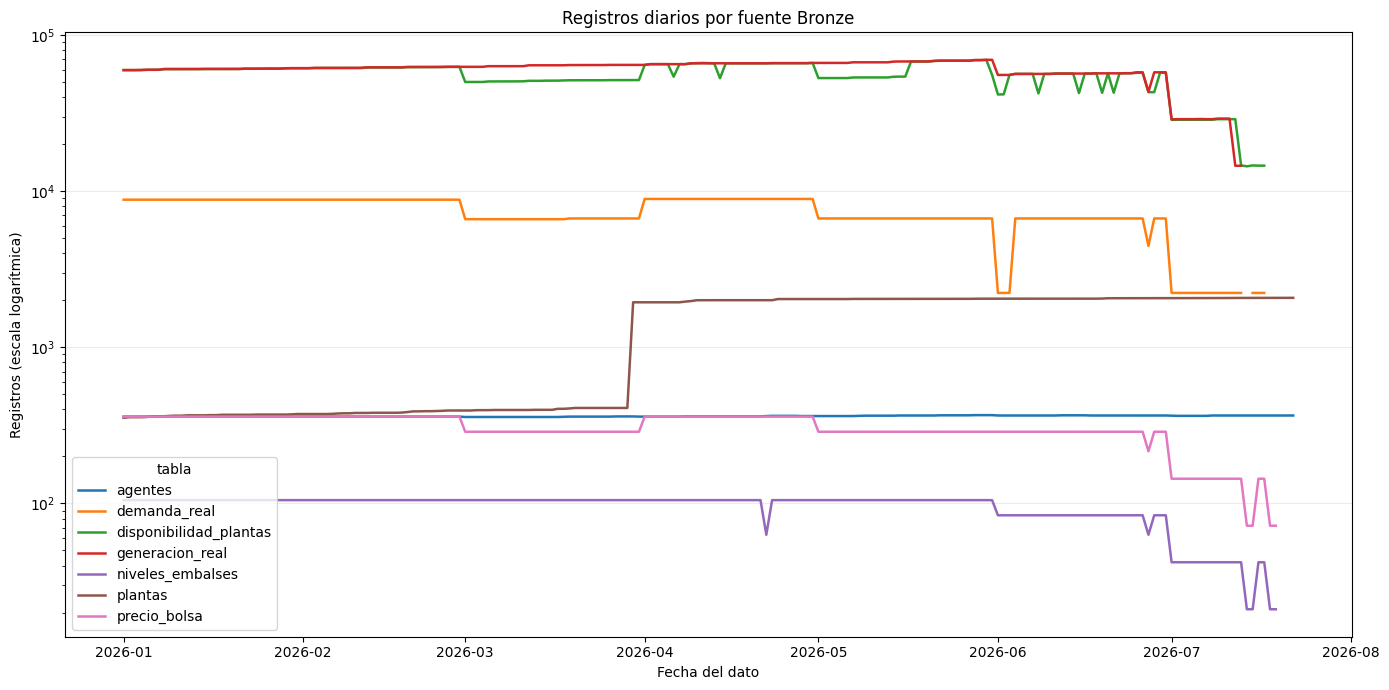

In [0]:
# Visualización acotada: volumen diario por fuente.
try:
    import matplotlib.pyplot as plt

    volumen_pdf = (
        volumen_diario_df
        .select("fecha_evento", "tabla", "registros")
        .orderBy("fecha_evento")
        .toPandas()
    )
    pivote = volumen_pdf.pivot(
        index="fecha_evento", columns="tabla", values="registros"
    )
    ax = pivote.plot(figsize=(14, 7), linewidth=1.8)
    ax.set_title("Registros diarios por fuente Bronze")
    ax.set_xlabel("Fecha del dato")
    ax.set_ylabel("Registros (escala logarítmica)")
    ax.set_yscale("log")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"No fue posible renderizar el gráfico: {exc}")

## 10. Revisiones entre versiones

In [0]:
revision_resumen_filas = []
revision_detalles = {}

for tabla in [
    "demanda_real", "disponibilidad_plantas",
    "generacion_real", "niveles_embalses", "precio_bolsa"
]:
    df = (
        spark.table(nombre_tabla(tabla))
        .select(
            *CONFIG[tabla]["llave_canonica"],
            "version",
            F.expr("try_cast(valor as double)").alias("valor_num")
        )
        .dropDuplicates()
    )
    por_llave = (
        df.groupBy(*CONFIG[tabla]["llave_canonica"])
        .agg(
            F.countDistinct("version").alias("n_versiones"),
            F.collect_set("version").alias("versiones"),
            F.min("valor_num").alias("valor_min"),
            F.max("valor_num").alias("valor_max"),
        )
        .withColumn("rango_revision", F.col("valor_max") - F.col("valor_min"))
        .withColumn(
            "pct_rango_sobre_max",
            F.when(
                F.abs(F.col("valor_max")) > 0,
                F.abs(F.col("rango_revision")) / F.abs(F.col("valor_max")) * 100
            )
        )
    )
    revisadas = por_llave.filter(F.col("n_versiones") > 1)
    r = revisadas.agg(
        F.count("*").alias("llaves_revisadas"),
        F.avg("n_versiones").alias("versiones_promedio"),
        F.max("n_versiones").alias("versiones_maximas"),
        F.avg("rango_revision").alias("rango_promedio"),
        F.expr("percentile_approx(rango_revision, 0.95, 10000)").alias("rango_p95"),
        F.max("rango_revision").alias("rango_maximo"),
        F.expr("percentile_approx(pct_rango_sobre_max, 0.5, 10000)").alias("pct_cambio_mediana"),
        F.expr("percentile_approx(pct_rango_sobre_max, 0.95, 10000)").alias("pct_cambio_p95"),
    ).first().asDict()
    r["tabla"] = tabla
    revision_resumen_filas.append(r)
    revision_detalles[tabla] = revisadas

revision_resumen_df = spark.createDataFrame(revision_resumen_filas)
display(revision_resumen_df.orderBy(F.desc("llaves_revisadas")))

llaves_revisadas,pct_cambio_mediana,pct_cambio_p95,rango_maximo,rango_p95,rango_promedio,tabla,versiones_maximas,versiones_promedio
2535432,0.0,0.0,376000.0,0.0,14.82926932767276,disponibilidad_plantas,5,4.320456632242553
2523720,0.0,0.0,212593.99,0.0,13.151437017577228,generacion_real,5,4.630583424468641
395448,0.0,0.32004219947005974,1047744.88,144.72000000000116,90.48340216665656,demanda_real,4,3.493111610123202
14112,1.0375350578721811,8.510913256638538,774.8510000000001,9.331999999999994,5.620488718820888,precio_bolsa,5,4.295918367346939
4116,0.0,0.0,0.0,0.0,0.0,niveles_embalses,5,4.6020408163265305


In [0]:
for tabla, detalle in revision_detalles.items():
    print(f"Mayores variaciones entre versiones — {tabla}")
    display(
        detalle
        .orderBy(F.desc("rango_revision"))
        .limit(30)
    )

Mayores variaciones entre versiones — demanda_real


fecha_hora,codigo_sic_agente,tipo_mercado,codigo_variable,codigo_duracion,n_versiones,versiones,valor_min,valor_max,rango_revision,pct_rango_sobre_max
2026-01-28T11:00:00,BEIC,Regulado,DdaReal,PT1H,4,"List(TXF, TX3, TX2, TXR)",242.61,1047987.49,1047744.88,99.9768499144966
2026-01-28T11:00:00,CSIC,Regulado,DdaReal,PT1H,4,"List(TXF, TX3, TX2, TXR)",578.31,969687.59,969109.2799999999,99.94036120437511
2026-04-13T15:00:00,CSIC,No Regulado,DdaReal,PT1H,4,"List(TXF, TX3, TXR, TX2)",109014.01,590590.62,481576.61,81.54152702255921
2026-04-13T15:00:00,CSIC,Regulado,DdaReal,PT1H,4,"List(TXF, TX3, TXR, TX2)",704065.91,1185642.52,481576.61,40.61735319681349
2026-04-13T16:00:00,CSIC,Regulado,DdaReal,PT1H,4,"List(TXF, TX3, TXR, TX2)",654304.22,1129557.08,475252.8600000001,42.074266844487404
2026-04-13T16:00:00,CSIC,No Regulado,DdaReal,PT1H,4,"List(TXF, TX3, TXR, TX2)",108178.16,583431.02,475252.86,81.45827762123446
2026-04-13T17:00:00,CSIC,No Regulado,DdaReal,PT1H,4,"List(TXF, TX3, TXR, TX2)",105634.21,575363.69,469729.4799999999,81.64044554149741
2026-04-13T17:00:00,CSIC,Regulado,DdaReal,PT1H,4,"List(TXF, TX3, TXR, TX2)",604011.67,1073741.15,469729.47999999986,43.74699432912671
2026-04-13T18:00:00,CSIC,Regulado,DdaReal,PT1H,4,"List(TXF, TX3, TXR, TX2)",675852.59,1114070.79,438218.20000000007,39.33486129727897
2026-04-13T18:00:00,CSIC,No Regulado,DdaReal,PT1H,4,"List(TXF, TX3, TXR, TX2)",114099.67,552317.87,438218.2,79.34166605907573


Mayores variaciones entre versiones — disponibilidad_plantas


fecha_hora,codigo_planta,codigo_variable,codigo_duracion,n_versiones,versiones,valor_min,valor_max,rango_revision,pct_rango_sobre_max
2026-01-31T18:00:00,TCDT,DispReal,PT1H,5,"List(TXF, TX3, TXR, TX2, TX1)",0.0,376000.0,376000.0,100.0
2026-02-25T18:00:00,GE32,DispReal,PT1H,5,"List(TX2, TXF, TX3, TXR, TX1)",0.0,270000.0,270000.0,100.0
2026-02-25T14:00:00,GE32,DispReal,PT1H,5,"List(TX1, TX2, TX3, TXF, TXR)",0.0,270000.0,270000.0,100.0
2026-02-25T12:00:00,GE32,DispReal,PT1H,5,"List(TX1, TX2, TXF, TXR, TX3)",0.0,270000.0,270000.0,100.0
2026-02-25T11:00:00,GE32,DispReal,PT1H,5,"List(TX1, TXF, TXR, TX3, TX2)",0.0,270000.0,270000.0,100.0
2026-02-25T08:00:00,GE32,DispReal,PT1H,5,"List(TX3, TXR, TX1, TX2, TXF)",0.0,270000.0,270000.0,100.0
2026-02-25T16:00:00,GE32,DispReal,PT1H,5,"List(TX3, TXF, TX1, TXR, TX2)",0.0,270000.0,270000.0,100.0
2026-02-25T13:00:00,GE32,DispReal,PT1H,5,"List(TX2, TX3, TXF, TX1, TXR)",0.0,270000.0,270000.0,100.0
2026-02-25T09:00:00,GE32,DispReal,PT1H,5,"List(TXR, TX2, TX1, TXF, TX3)",0.0,270000.0,270000.0,100.0
2026-02-25T15:00:00,GE32,DispReal,PT1H,5,"List(TXF, TX2, TXR, TX1, TX3)",0.0,270000.0,270000.0,100.0


Mayores variaciones entre versiones — generacion_real


fecha_hora,codigo_planta,codigo_sic_agente,codigo_variable,codigo_duracion,n_versiones,versiones,valor_min,valor_max,rango_revision,pct_rango_sobre_max
2026-02-05T12:00:00,TEC1,TEMG,GReal,PT1H,5,"List(TX1, TX3, TXR, TX2, TXF)",0.0,212593.99,212593.99,100.0
2026-02-05T13:00:00,TEC1,TEMG,GReal,PT1H,5,"List(TXR, TX2, TXF, TX3, TX1)",0.0,212569.57,212569.57,100.0
2026-02-05T11:00:00,TEC1,TEMG,GReal,PT1H,5,"List(TXF, TX2, TXR, TX3, TX1)",0.0,212564.09,212564.09,100.0
2026-02-05T14:00:00,TEC1,TEMG,GReal,PT1H,5,"List(TXF, TX1, TX2, TXR, TX3)",0.0,212544.3,212544.3,100.0
2026-02-05T10:00:00,TEC1,TEMG,GReal,PT1H,5,"List(TX3, TX2, TX1, TXR, TXF)",0.0,212535.88,212535.88,100.0
2026-02-05T15:00:00,TEC1,TEMG,GReal,PT1H,5,"List(TXR, TXF, TX1, TX3, TX2)",0.0,212531.25,212531.25,100.0
2026-02-05T07:00:00,TEC1,TEMG,GReal,PT1H,5,"List(TX1, TXR, TXF, TX2, TX3)",0.0,212529.98,212529.98,100.0
2026-02-05T08:00:00,TEC1,TEMG,GReal,PT1H,5,"List(TX3, TX1, TXF, TXR, TX2)",0.0,212529.14,212529.14,100.0
2026-02-05T06:00:00,TEC1,TEMG,GReal,PT1H,5,"List(TX3, TXF, TX1, TXR, TX2)",0.0,212524.51,212524.51,100.0
2026-02-05T09:00:00,TEC1,TEMG,GReal,PT1H,5,"List(TXF, TX2, TXR, TX3, TX1)",0.0,212522.82,212522.82,100.0


Mayores variaciones entre versiones — niveles_embalses


fecha_inicio,codigo_planta,codigo_variable,codigo_duracion,n_versiones,versiones,valor_min,valor_max,rango_revision,pct_rango_sobre_max
2026-01-04,GTPE,NEM,P1D,5,"List(TXR, TX1, TXF, TX3, TX2)",3.91242924E9,3.91242924E9,0.0,0.0
2026-04-25,SOG1,NEM,P1D,5,"List(TX1, TXR, TX3, TX2, TXF)",8.6271647E8,8.6271647E8,0.0,0.0
2026-01-03,ALBG,NEM,P1D,5,"List(TXF, TX1, TX3, TX2, TXR)",4983564.0,4983564.0,0.0,0.0
2026-03-21,SNCR,NEM,P1D,5,"List(TX2, TXR, TXF, TX3, TX1)",2.816992E7,2.816992E7,0.0,0.0
2026-04-25,GTPE,NEM,P1D,5,"List(TX1, TXF, TXR, TX3, TX2)",3.33825156E9,3.33825156E9,0.0,0.0
2026-04-06,CHBG,NEM,P1D,5,"List(TX3, TXR, TXF, TX1, TX2)",9.7940934E7,9.7940934E7,0.0,0.0
2026-01-28,GTPE,NEM,P1D,5,"List(TX1, TXR, TXF, TX2, TX3)",3.6997929E9,3.6997929E9,0.0,0.0
2026-02-09,PRC2,NEM,P1D,5,"List(TXF, TXR, TX1, TX2, TX3)",8.7605172E7,8.7605172E7,0.0,0.0
2026-01-04,PGUG,NEM,P1D,5,"List(TX3, TX2, TX1, TXR, TXF)",3.1736531E9,3.1736531E9,0.0,0.0
2026-02-06,ALBG,NEM,P1D,5,"List(TX1, TX2, TXR, TXF, TX3)",2.3677618E7,2.3677618E7,0.0,0.0


Mayores variaciones entre versiones — precio_bolsa


fecha_hora,codigo_variable,codigo_duracion,n_versiones,versiones,valor_min,valor_max,rango_revision,pct_rango_sobre_max
2026-04-22T19:00:00,PB_Nal,PT1H,5,"List(TX3, TXR, TX2, TXF, TX1)",305.7356,1080.5866,774.8510000000001,71.70651570174941
2026-04-22T19:00:00,PB_Tie,PT1H,5,"List(TX2, TX1, TXR, TX3, TXF)",305.3348,1073.7063,768.3715000000001,71.5625399608813
2026-04-22T19:00:00,PB_Int,PT1H,5,"List(TX3, TX1, TXF, TXR, TX2)",305.3348,1073.7063,768.3715000000001,71.5625399608813
2026-04-08T20:00:00,PB_Nal,PT1H,5,"List(TX1, TXR, TX2, TX3, TXF)",397.3678,1087.5217,690.1539,63.46116128073582
2026-04-08T20:00:00,PB_Tie,PT1H,5,"List(TXF, TX3, TX2, TX1, TXR)",382.1719,1072.034,689.8621,64.3507668600063
2026-04-08T20:00:00,PB_Int,PT1H,5,"List(TXR, TX3, TXF, TX1, TX2)",382.1719,1072.034,689.8621,64.3507668600063
2026-06-16T20:00:00,PB_Nal,PT1H,4,"List(TX2, TX1, TX3, TXR)",671.1933,1259.9135,588.7202000000001,46.7270332447426
2026-06-16T21:00:00,PB_Nal,PT1H,4,"List(TX1, TX2, TX3, TXR)",671.1933,1256.129,584.9356999999999,46.566530985273005
2026-06-16T20:00:00,PB_Int,PT1H,4,"List(TX1, TX2, TX3, TXR)",665.0,1249.0,584.0,46.75740592473979
2026-06-16T20:00:00,PB_Tie,PT1H,4,"List(TX2, TX1, TX3, TXR)",665.0,1249.0,584.0,46.75740592473979


In [0]:
seleccion_version_frames = []
for tabla in [
    "demanda_real", "disponibilidad_plantas",
    "generacion_real", "niveles_embalses", "precio_bolsa"
]:
    elegido = (
        seleccionar_version_canonica(tabla)
        .groupBy("version")
        .agg(F.count("*").alias("llaves_seleccionadas"))
        .withColumn("tabla", F.lit(tabla))
    )
    seleccion_version_frames.append(elegido)

seleccion_version_df = reduce(
    lambda a, b: a.unionByName(b, allowMissingColumns=True),
    seleccion_version_frames,
)
display(seleccion_version_df.orderBy("tabla", F.desc("llaves_seleccionadas")))

version,llaves_seleccionadas,tabla
TXF,335184,demanda_real
TXR,60264,demanda_real
TX2,42408,demanda_real
TXF,1936584,disponibilidad_plantas
TXR,426264,disponibilidad_plantas
TX2,188280,disponibilidad_plantas
TX1,58656,disponibilidad_plantas
TXF,1937568,generacion_real
TXR,426840,generacion_real
TX2,160032,generacion_real


## 11. Calidad de identificadores y estabilidad de nombres

In [0]:
identificadores = [
    ("agentes", "codigo_sic_agente"),
    ("demanda_real", "codigo_sic_agente"),
    ("generacion_real", "codigo_sic_agente"),
    ("plantas", "codigo_sic_agente"),
    ("plantas", "codigo_planta"),
    ("generacion_real", "codigo_planta"),
    ("disponibilidad_plantas", "codigo_planta"),
    ("niveles_embalses", "codigo_planta"),
    ("embalses", "codigo_embalse"),
]

calidad_id_filas = []
for tabla, columna in identificadores:
    df = spark.table(nombre_tabla(tabla))
    r = df.agg(
        F.count("*").alias("registros"),
        F.sum(F.when(F.col(columna).isNull(), 1).otherwise(0)).alias("nulos"),
        F.sum(
            F.when(F.trim(F.col(columna)) == "", 1).otherwise(0)
        ).alias("vacios"),
        F.sum(
            F.when(F.col(columna) != F.trim(F.col(columna)), 1).otherwise(0)
        ).alias("con_espacios_externos"),
        F.sum(
            F.when(F.col(columna) != F.upper(F.col(columna)), 1).otherwise(0)
        ).alias("no_mayuscula"),
        F.min(F.length(F.trim(F.col(columna)))).alias("longitud_min"),
        F.max(F.length(F.trim(F.col(columna)))).alias("longitud_max"),
        F.approx_count_distinct(columna).alias("distintos"),
    ).first().asDict()
    r.update({"tabla": tabla, "columna": columna})
    calidad_id_filas.append(r)

calidad_id_df = spark.createDataFrame(calidad_id_filas)
display(calidad_id_df.orderBy("columna", "tabla"))

columna,con_espacios_externos,distintos,longitud_max,longitud_min,no_mayuscula,nulos,registros,tabla,vacios
codigo_embalse,0,33,8,4,0,0,32,embalses,0
codigo_planta,0,668,4,4,0,0,11028576,disponibilidad_plantas,0
codigo_planta,0,664,4,4,0,0,11716152,generacion_real,0
codigo_planta,0,19,4,4,0,0,19026,niveles_embalses,0
codigo_planta,0,2176,4,4,0,0,268107,plantas,0
codigo_sic_agente,0,390,4,4,0,0,73570,agentes,0
codigo_sic_agente,0,64,4,4,0,0,1423752,demanda_real,0
codigo_sic_agente,0,110,4,4,0,0,11716152,generacion_real,0
codigo_sic_agente,0,125,4,4,0,0,268107,plantas,0


In [0]:
estabilidad_frames = []
for tabla, codigo, nombre in [
    ("agentes", "codigo_sic_agente", "nombre_agente"),
    ("plantas", "codigo_planta", "nombre_planta"),
    ("embalses", "codigo_embalse", "nombre_embalse"),
]:
    df = spark.table(nombre_tabla(tabla))
    cambios = (
        df.groupBy(F.upper(F.trim(F.col(codigo))).alias("codigo_normalizado"))
        .agg(
            F.countDistinct(normalizar_texto(F.col(nombre))).alias("nombres_distintos"),
            F.collect_set(nombre).alias("nombres_observados"),
        )
        .filter(F.col("nombres_distintos") > 1)
        .withColumn("tabla", F.lit(tabla))
        .withColumn("campo_codigo", F.lit(codigo))
    )
    estabilidad_frames.append(cambios)

estabilidad_nombres_df = reduce(
    lambda a, b: a.unionByName(b, allowMissingColumns=True),
    estabilidad_frames,
)
display(
    estabilidad_nombres_df
    .orderBy(F.desc("nombres_distintos"), "tabla")
    .limit(200)
)

codigo_normalizado,nombres_distintos,nombres_observados,tabla,campo_codigo
NESC,2,"List( NES TRADING S.A.S. E.S.P., NOVA ENERGY STAR S.A.S. E.S.P.)",agentes,codigo_sic_agente
BTGC,2,"List(BTG PACTUAL COMERCIALIZADORA DE ENERGÍA S.A.S. E.S.P, BTG PACTUAL COMMODITIES COLOMBIA S.A.S. E.S.P.)",agentes,codigo_sic_agente
SOEG,2,"List(COREX ENERGY S.A.S. E.S.P., SOUTH32 ENERGY S.A.S E.S.P)",agentes,codigo_sic_agente
SOEC,2,"List(SOUTH32 ENERGY S.A.S E.S.P, COREX ENERGY S.A.S. E.S.P.)",agentes,codigo_sic_agente
TEMG,2,"List(TERMOEMCALI I S.A. E.S.P., TERMOEMCALI I S.A E.S.P)",agentes,codigo_sic_agente
ARG1,2,"List(ARGOS CARTAGENA 1, TERMOFENIX I 1)",plantas,codigo_planta
2S6Q,2,"List(AUTOG YAGUARITO, AUTOG YAGUARITO 1)",plantas,codigo_planta
5FPL,2,"List(GRANJA SOLAR LA GARITA, GD SIRIUS)",plantas,codigo_planta
5GFB,2,"List(GD JARDINCITO, GD WE9)",plantas,codigo_planta
5QTJ,2,"List(GD ELECTRA, GD GRANJA SOLAR SAN AGUSTIN)",plantas,codigo_planta


## 12. Integridad referencial y cobertura entre fuentes

In [0]:
plantas_codigos = (
    spark.table(nombre_tabla("plantas"))
    .select(F.upper(F.trim("codigo_planta")).alias("codigo"))
    .filter(F.col("codigo").isNotNull() & (F.col("codigo") != ""))
    .distinct()
)
agentes_codigos = (
    spark.table(nombre_tabla("agentes"))
    .select(F.upper(F.trim("codigo_sic_agente")).alias("codigo"))
    .filter(F.col("codigo").isNotNull() & (F.col("codigo") != ""))
    .distinct()
)

integridad_filas = []
orfanos_frames = []

def evaluar_fk(tabla_hija, columna_hija, padre_df, relacion):
    hijos = (
        spark.table(nombre_tabla(tabla_hija))
        .select(F.upper(F.trim(F.col(columna_hija))).alias("codigo"))
        .filter(F.col("codigo").isNotNull() & (F.col("codigo") != ""))
        .distinct()
    )
    orfanos = hijos.join(padre_df, "codigo", "left_anti")
    total = hijos.count()
    n_orfanos = orfanos.count()
    integridad_filas.append({
        "relacion": relacion,
        "tabla_hija": tabla_hija,
        "columna_hija": columna_hija,
        "codigos_hijos": total,
        "codigos_huerfanos": n_orfanos,
        "cobertura_pct": round((total - n_orfanos) / total * 100, 4) if total else None,
    })
    orfanos_frames.append(
        orfanos
        .withColumn("relacion", F.lit(relacion))
        .withColumn("tabla_hija", F.lit(tabla_hija))
    )

for tabla in ["generacion_real", "disponibilidad_plantas", "niveles_embalses"]:
    evaluar_fk(
        tabla, "codigo_planta", plantas_codigos,
        f"{tabla}.codigo_planta -> plantas.codigo_planta"
    )

for tabla in ["demanda_real", "generacion_real", "plantas"]:
    evaluar_fk(
        tabla, "codigo_sic_agente", agentes_codigos,
        f"{tabla}.codigo_sic_agente -> agentes.codigo_sic_agente"
    )

integridad_df = spark.createDataFrame(integridad_filas)
display(integridad_df.orderBy("cobertura_pct"))

orfanos_df = reduce(
    lambda a, b: a.unionByName(b, allowMissingColumns=True),
    orfanos_frames,
)
display(orfanos_df.orderBy("relacion", "codigo").limit(300))

cobertura_pct,codigos_hijos,codigos_huerfanos,columna_hija,relacion,tabla_hija
72.9032,620,168,codigo_planta,disponibilidad_plantas.codigo_planta -> plantas.codigo_planta,disponibilidad_plantas
73.6928,612,161,codigo_planta,generacion_real.codigo_planta -> plantas.codigo_planta,generacion_real
100.0,21,0,codigo_planta,niveles_embalses.codigo_planta -> plantas.codigo_planta,niveles_embalses
100.0,65,0,codigo_sic_agente,demanda_real.codigo_sic_agente -> agentes.codigo_sic_agente,demanda_real
100.0,111,0,codigo_sic_agente,generacion_real.codigo_sic_agente -> agentes.codigo_sic_agente,generacion_real
100.0,128,0,codigo_sic_agente,plantas.codigo_sic_agente -> agentes.codigo_sic_agente,plantas


codigo,relacion,tabla_hija
2S8G,disponibilidad_plantas.codigo_planta -> plantas.codigo_planta,disponibilidad_plantas
2TYI,disponibilidad_plantas.codigo_planta -> plantas.codigo_planta,disponibilidad_plantas
2VJS,disponibilidad_plantas.codigo_planta -> plantas.codigo_planta,disponibilidad_plantas
2YB9,disponibilidad_plantas.codigo_planta -> plantas.codigo_planta,disponibilidad_plantas
2ZHY,disponibilidad_plantas.codigo_planta -> plantas.codigo_planta,disponibilidad_plantas
2ZP9,disponibilidad_plantas.codigo_planta -> plantas.codigo_planta,disponibilidad_plantas
3A44,disponibilidad_plantas.codigo_planta -> plantas.codigo_planta,disponibilidad_plantas
3ACC,disponibilidad_plantas.codigo_planta -> plantas.codigo_planta,disponibilidad_plantas
3B4L,disponibilidad_plantas.codigo_planta -> plantas.codigo_planta,disponibilidad_plantas
3BZB,disponibilidad_plantas.codigo_planta -> plantas.codigo_planta,disponibilidad_plantas


In [0]:
plantas_nombres = (
    spark.table(nombre_tabla("plantas"))
    .select(normalizar_texto(F.col("nombre_planta")).alias("nombre"))
    .filter(F.col("nombre").isNotNull() & (F.col("nombre") != ""))
    .distinct()
)
embalses_nombres = (
    spark.table(nombre_tabla("embalses"))
    .select(normalizar_texto(F.col("nombre_embalse")).alias("nombre"))
    .filter(F.col("nombre").isNotNull() & (F.col("nombre") != ""))
    .distinct()
)
relaciones = spark.table(nombre_tabla("plantas_reservorios"))

plantas_relacion = (
    relaciones
    .select(normalizar_texto(F.col("nombre_planta")).alias("nombre"))
    .distinct()
)
reservorios_relacion = (
    relaciones
    .select(normalizar_texto(F.col("nombre_reservorio")).alias("nombre"))
    .distinct()
)

plantas_sin_match = plantas_relacion.join(plantas_nombres, "nombre", "left_anti")
reservorios_sin_match = reservorios_relacion.join(embalses_nombres, "nombre", "left_anti")

integridad_nombres_df = spark.createDataFrame([
    {
        "relacion": "plantas_reservorios.nombre_planta -> plantas.nombre_planta",
        "valores_relacion": plantas_relacion.count(),
        "sin_match_exacto_normalizado": plantas_sin_match.count(),
    },
    {
        "relacion": "plantas_reservorios.nombre_reservorio -> embalses.nombre_embalse",
        "valores_relacion": reservorios_relacion.count(),
        "sin_match_exacto_normalizado": reservorios_sin_match.count(),
    },
])
display(integridad_nombres_df)

print("Plantas sin correspondencia exacta normalizada")
display(plantas_sin_match)
print("Reservorios sin correspondencia exacta normalizada")
display(reservorios_sin_match)

relacion,sin_match_exacto_normalizado,valores_relacion
plantas_reservorios.nombre_planta -> plantas.nombre_planta,1,20
plantas_reservorios.nombre_reservorio -> embalses.nombre_embalse,5,23


Plantas sin correspondencia exacta normalizada


nombre
SOGAMOSOS


Reservorios sin correspondencia exacta normalizada


nombre
TOPOROCO
PORCE III
URRA1
PORCE II
CALIMA 1


## 13. Coherencia operativa entre generación, disponibilidad y capacidad

In [0]:
generacion_hora = (
    seleccionar_version_canonica("generacion_real")
    .withColumn("fecha_hora_ts", fecha_evento("generacion_real"))
    .withColumn("codigo_planta_norm", F.upper(F.trim("codigo_planta")))
    .withColumn("generacion_kwh", F.expr("try_cast(valor as double)"))
    .groupBy("fecha_hora_ts", "codigo_planta_norm")
    .agg(F.sum("generacion_kwh").alias("generacion_kwh"))
)

disponibilidad_hora = (
    seleccionar_version_canonica("disponibilidad_plantas")
    .withColumn("fecha_hora_ts", fecha_evento("disponibilidad_plantas"))
    .withColumn("codigo_planta_norm", F.upper(F.trim("codigo_planta")))
    .withColumn("disponibilidad_kwh", F.expr("try_cast(valor as double)"))
    .groupBy("fecha_hora_ts", "codigo_planta_norm")
    .agg(F.sum("disponibilidad_kwh").alias("disponibilidad_kwh"))
)

comparacion_operativa = (
    generacion_hora.join(
        disponibilidad_hora,
        ["fecha_hora_ts", "codigo_planta_norm"],
        "inner"
    )
    .withColumn(
        "ratio_generacion_disponibilidad",
        F.when(
            F.col("disponibilidad_kwh") > 0,
            F.col("generacion_kwh") / F.col("disponibilidad_kwh")
        )
    )
)

resumen_operativo = comparacion_operativa.agg(
    F.count("*").alias("horas_comparables"),
    F.sum(
        F.when(
            F.col("generacion_kwh") > F.col("disponibilidad_kwh") * TOLERANCIA_OPERATIVA,
            1
        ).otherwise(0)
    ).alias("horas_generacion_supera_disponibilidad_5pct"),
    F.sum(
        F.when(
            (F.col("disponibilidad_kwh") == 0)
            & (F.col("generacion_kwh") > 0),
            1
        ).otherwise(0)
    ).alias("horas_disponibilidad_cero_con_generacion"),
    F.expr(
        "percentile_approx(ratio_generacion_disponibilidad, 0.5, 10000)"
    ).alias("ratio_mediana"),
    F.expr(
        "percentile_approx(ratio_generacion_disponibilidad, 0.95, 10000)"
    ).alias("ratio_p95"),
    F.max("ratio_generacion_disponibilidad").alias("ratio_maximo"),
)
display(resumen_operativo)

horas_comparables,horas_generacion_supera_disponibilidad_5pct,horas_disponibilidad_cero_con_generacion,ratio_mediana,ratio_p95,ratio_maximo
2550480,13176,2873,1.0,1.0000971415016013,81.6827


In [0]:
anomalias_por_planta = (
    comparacion_operativa
    .groupBy("codigo_planta_norm")
    .agg(
        F.count("*").alias("horas_comparables"),
        F.sum(
            F.when(
                F.col("generacion_kwh") > F.col("disponibilidad_kwh") * TOLERANCIA_OPERATIVA,
                1
            ).otherwise(0)
        ).alias("horas_supera_5pct"),
        F.sum(
            F.when(
                (F.col("disponibilidad_kwh") == 0)
                & (F.col("generacion_kwh") > 0),
                1
            ).otherwise(0)
        ).alias("horas_disp_cero_con_gen"),
        F.max("ratio_generacion_disponibilidad").alias("ratio_maximo"),
    )
    .withColumn(
        "pct_horas_supera_5pct",
        F.round(F.col("horas_supera_5pct") / F.col("horas_comparables") * 100, 4)
    )
    .orderBy(F.desc("horas_supera_5pct"))
)
display(anomalias_por_planta.limit(100))

codigo_planta_norm,horas_comparables,horas_supera_5pct,horas_disp_cero_con_gen,ratio_maximo,pct_horas_supera_5pct
PSUA,4656,1435,1435,null,30.8204
ESMR,4656,1435,5,2.396774,30.8204
HMIN,4656,1422,4,2.3755025,30.5412
CUC1,4656,1172,5,3.8818033333333335,25.1718
TYP1,4656,1052,0,2.37751,22.5945
MOY1,4656,997,0,2.669101153846154,21.4132
CLL1,4656,885,1,2.340508125,19.0077
SMI1,4656,583,0,1.8443919230769232,12.5215
3INX,4656,397,119,6.028181818181818,8.5266
3IQA,4656,340,115,1.60931,7.3024


In [0]:
plantas_base = (
    spark.table(nombre_tabla("plantas"))
    .withColumn("codigo_planta_norm", F.upper(F.trim("codigo_planta")))
    .withColumn("fecha_planta", F.to_date("fecha"))
    .withColumn("capacidad_kw", F.expr("try_cast(cap_efectiva_neta as double)"))
)
ventana_planta = Window.partitionBy("codigo_planta_norm").orderBy(
    F.col("fecha_planta").desc_nulls_last(),
    F.col("ingestion_timestamp").desc_nulls_last(),
    F.col("id").desc_nulls_last(),
)
plantas_actuales = (
    plantas_base
    .withColumn("_rn", F.row_number().over(ventana_planta))
    .filter(F.col("_rn") == 1)
    .select(
        "codigo_planta_norm", "nombre_planta", "codigo_sic_agente",
        "tipo_generacion", "capacidad_kw"
    )
)

generacion_capacidad = (
    generacion_hora.join(plantas_actuales, "codigo_planta_norm", "inner")
    .withColumn(
        "factor_horario",
        F.when(F.col("capacidad_kw") > 0, F.col("generacion_kwh") / F.col("capacidad_kw"))
    )
)

resumen_capacidad = generacion_capacidad.agg(
    F.count("*").alias("horas_con_maestro"),
    F.sum(F.when(F.col("capacidad_kw").isNull(), 1).otherwise(0)).alias("horas_sin_capacidad"),
    F.sum(
        F.when(F.col("generacion_kwh") > F.col("capacidad_kw") * TOLERANCIA_OPERATIVA, 1)
         .otherwise(0)
    ).alias("horas_generacion_supera_capacidad_5pct"),
    F.expr("percentile_approx(factor_horario, 0.5, 10000)").alias("factor_mediana"),
    F.expr("percentile_approx(factor_horario, 0.95, 10000)").alias("factor_p95"),
    F.max("factor_horario").alias("factor_maximo"),
)
display(resumen_capacidad)

display(
    generacion_capacidad
    .filter(F.col("factor_horario") > TOLERANCIA_OPERATIVA)
    .orderBy(F.desc("factor_horario"))
    .select(
        "fecha_hora_ts", "codigo_planta_norm", "nombre_planta",
        "tipo_generacion", "generacion_kwh", "capacidad_kw", "factor_horario"
    )
    .limit(100)
)

horas_con_maestro,horas_sin_capacidad,horas_generacion_supera_capacidad_5pct,factor_mediana,factor_p95,factor_maximo
2000424,0,33094,0.15222222222222223,0.9932106666666667,2.37751


fecha_hora_ts,codigo_planta_norm,nombre_planta,tipo_generacion,generacion_kwh,capacidad_kw,factor_horario
2026-04-28T08:00:00.000Z,TYP1,TERMOYOPAL 1,Termica,19020.08,8000.0,2.37751
2026-06-11T00:00:00.000Z,TYP1,TERMOYOPAL 1,Termica,18961.05,8000.0,2.37013125
2026-06-07T23:00:00.000Z,TYP1,TERMOYOPAL 1,Termica,18369.61,8000.0,2.29620125
2026-06-07T22:00:00.000Z,TYP1,TERMOYOPAL 1,Termica,18298.27,8000.0,2.28728375
2026-06-08T00:00:00.000Z,TYP1,TERMOYOPAL 1,Termica,18295.37,8000.0,2.28692125
2026-06-07T21:00:00.000Z,TYP1,TERMOYOPAL 1,Termica,18270.15,8000.0,2.28376875
2026-06-10T23:00:00.000Z,TYP1,TERMOYOPAL 1,Termica,18226.64,8000.0,2.27833
2026-06-07T20:00:00.000Z,TYP1,TERMOYOPAL 1,Termica,18207.48,8000.0,2.275935
2026-06-07T01:00:00.000Z,TYP1,TERMOYOPAL 1,Termica,18089.52,8000.0,2.26119
2026-04-29T07:00:00.000Z,TYP1,TERMOYOPAL 1,Termica,18061.28,8000.0,2.25766


## 14. Comportamiento del sistema: generación, demanda, disponibilidad y precio

In [0]:
demanda_hora = (
    seleccionar_version_canonica("demanda_real")
    .withColumn("fecha_hora_ts", fecha_evento("demanda_real"))
    .withColumn("demanda_kwh", F.expr("try_cast(valor as double)"))
    .groupBy("fecha_hora_ts")
    .agg(F.sum("demanda_kwh").alias("demanda_kwh"))
)

generacion_sistema_hora = (
    generacion_hora.groupBy("fecha_hora_ts")
    .agg(F.sum("generacion_kwh").alias("generacion_kwh"))
)

disponibilidad_sistema_hora = (
    disponibilidad_hora.groupBy("fecha_hora_ts")
    .agg(F.sum("disponibilidad_kwh").alias("disponibilidad_kwh"))
)

operacion_hora = (
    generacion_sistema_hora
    .join(demanda_hora, "fecha_hora_ts", "full")
    .join(disponibilidad_sistema_hora, "fecha_hora_ts", "full")
)

operacion_diaria = (
    operacion_hora
    .withColumn("fecha", F.to_date("fecha_hora_ts"))
    .groupBy("fecha")
    .agg(
        (F.sum("generacion_kwh") / F.lit(1_000_000)).alias("generacion_gwh"),
        (F.sum("demanda_kwh") / F.lit(1_000_000)).alias("demanda_gwh"),
        (F.sum("disponibilidad_kwh") / F.lit(1_000_000)).alias("disponibilidad_gwh"),
        F.countDistinct(
            F.when(F.col("generacion_kwh").isNotNull(), F.hour("fecha_hora_ts"))
        ).alias("horas_generacion"),
        F.countDistinct(
            F.when(F.col("demanda_kwh").isNotNull(), F.hour("fecha_hora_ts"))
        ).alias("horas_demanda"),
        F.countDistinct(
            F.when(F.col("disponibilidad_kwh").isNotNull(), F.hour("fecha_hora_ts"))
        ).alias("horas_disponibilidad"),
    )
    .withColumn(
        "margen_generacion_demanda_gwh",
        F.col("generacion_gwh") - F.col("demanda_gwh")
    )
    .withColumn(
        "utilizacion_disponibilidad_pct",
        F.when(
            F.col("disponibilidad_gwh") > 0,
            F.col("generacion_gwh") / F.col("disponibilidad_gwh") * 100
        )
    )
)

display(operacion_diaria.orderBy(F.desc("fecha")).limit(250))

fecha,generacion_gwh,demanda_gwh,disponibilidad_gwh,horas_generacion,horas_demanda,horas_disponibilidad,margen_generacion_demanda_gwh,utilizacion_disponibilidad_pct
2026-07-17,null,256.05491053000003,376.70555561000003,0,24,24,null,null
2026-07-16,null,256.31925068000004,379.5135100400001,0,24,24,null,null
2026-07-15,null,254.68329943,367.68138937,0,24,24,null,null
2026-07-14,null,null,366.47906723000006,0,0,24,null,null
2026-07-13,225.53335672,220.18475954,370.40042158999995,24,24,24,5.348597180000013,60.889065879532176
2026-07-12,222.45548854999998,216.37571095,365.18677265,24,24,24,6.0797775999999715,60.91553835198855
2026-07-11,245.58136998,238.98268480000002,373.25997187,24,24,24,6.59868517999999,65.79365281245097
2026-07-10,255.18661242000002,249.44849059000003,365.18964122000006,24,24,24,5.738121829999983,69.87783431301348
2026-07-09,259.26913568000003,252.23066982000003,381.7176934400001,24,24,24,7.038465860000002,67.92169714311473
2026-07-08,262.54998818,256.68120244000005,386.91745285999997,24,24,24,5.868785739999964,67.85684807942732


In [0]:
mercado_diario = (
    seleccionar_version_canonica("demanda_real")
    .withColumn("fecha", F.to_date(fecha_evento("demanda_real")))
    .withColumn("demanda_gwh", F.expr("try_cast(valor as double)") / F.lit(1_000_000))
    .groupBy("fecha", "tipo_mercado")
    .agg(F.sum("demanda_gwh").alias("demanda_gwh"))
)
display(mercado_diario.orderBy(F.desc("fecha"), "tipo_mercado").limit(400))

agentes_demanda = (
    seleccionar_version_canonica("demanda_real")
    .withColumn("demanda_gwh", F.expr("try_cast(valor as double)") / F.lit(1_000_000))
    .groupBy("codigo_sic_agente", "tipo_mercado")
    .agg(
        F.sum("demanda_gwh").alias("demanda_gwh"),
        F.min(CONFIG["demanda_real"]["fecha"]).alias("primera_fecha"),
        F.max(CONFIG["demanda_real"]["fecha"]).alias("ultima_fecha"),
    )
    .orderBy(F.desc("demanda_gwh"))
)
display(agentes_demanda.limit(100))

fecha,tipo_mercado,demanda_gwh
2026-07-17,No Regulado,76.18278513
2026-07-17,Regulado,179.87212540000002
2026-07-16,No Regulado,76.33235389000001
2026-07-16,Regulado,179.98689679
2026-07-15,No Regulado,75.45577329
2026-07-15,Regulado,179.22752614
2026-07-13,No Regulado,63.23144460000001
2026-07-13,Regulado,156.95331494
2026-07-12,No Regulado,61.961174119999995
2026-07-12,Regulado,154.41453683


codigo_sic_agente,tipo_mercado,demanda_gwh,primera_fecha,ultima_fecha
ENDC,Regulado,5946.0525841,2026-01-01T00:00:00,2026-07-17T23:00:00
CSIC,Regulado,5050.489791659999,2026-01-01T00:00:00,2026-07-17T23:00:00
CMMC,Regulado,4884.74649065,2026-01-01T00:00:00,2026-07-17T23:00:00
EPMC,Regulado,4366.34396557,2026-01-01T00:00:00,2026-07-17T23:00:00
EPMC,No Regulado,2530.3126064100006,2026-01-01T00:00:00,2026-07-17T23:00:00
GECC,No Regulado,2265.6465665799997,2026-01-01T00:00:00,2026-07-17T23:00:00
ISGC,No Regulado,2176.2148950799997,2026-01-01T00:00:00,2026-07-17T23:00:00
ENDC,No Regulado,1992.5567607099995,2026-01-01T00:00:00,2026-07-17T23:00:00
EPSC,Regulado,1509.9641995599998,2026-01-01T00:00:00,2026-07-17T23:00:00
EMIC,Regulado,1373.26169908,2026-01-01T00:00:00,2026-07-17T23:00:00


In [0]:
precio_diario = (
    seleccionar_version_canonica("precio_bolsa")
    .withColumn("fecha", F.to_date(fecha_evento("precio_bolsa")))
    .withColumn("precio", F.expr("try_cast(valor as double)"))
    .groupBy("fecha", "codigo_variable")
    .agg(
        F.avg("precio").alias("precio_promedio_cop_kwh"),
        F.min("precio").alias("precio_minimo_cop_kwh"),
        F.max("precio").alias("precio_maximo_cop_kwh"),
        F.countDistinct(F.hour(fecha_evento("precio_bolsa"))).alias("horas"),
    )
)
display(precio_diario.orderBy(F.desc("fecha"), "codigo_variable").limit(400))

fecha,codigo_variable,precio_promedio_cop_kwh,precio_minimo_cop_kwh,precio_maximo_cop_kwh,horas
2026-07-19,PB_Int,824.6286249999999,656.0,960.0,24
2026-07-19,PB_Nal,825.2605250000001,656.6319,960.6319,24
2026-07-19,PB_Tie,824.6286249999999,656.0,960.0,24
2026-07-18,PB_Int,791.1005833333334,651.0,960.0,24
2026-07-18,PB_Nal,791.5069833333332,651.4064,960.4064,24
2026-07-18,PB_Tie,791.1005833333334,651.0,960.0,24
2026-07-17,PB_Int,856.484375,650.0,1205.0,24
2026-07-17,PB_Nal,856.9286749999997,650.4443,1205.4443,24
2026-07-17,PB_Tie,856.484375,650.0,1205.0,24
2026-07-16,PB_Int,835.2411666666667,651.0,1210.0,24


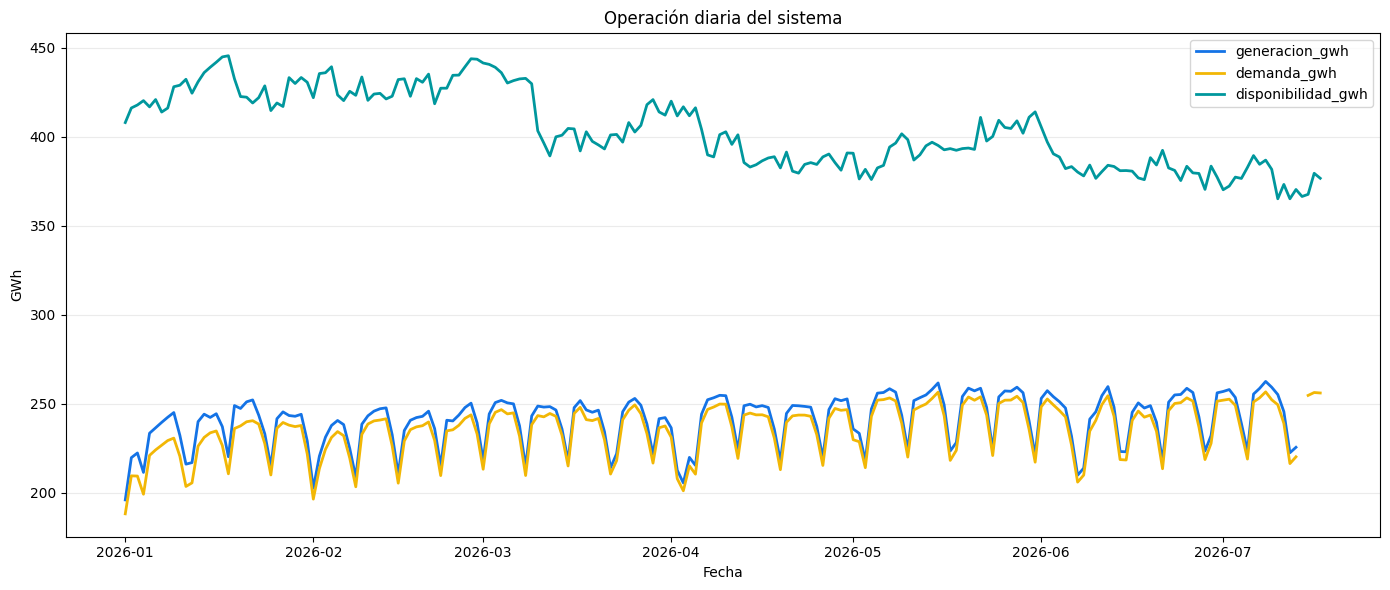

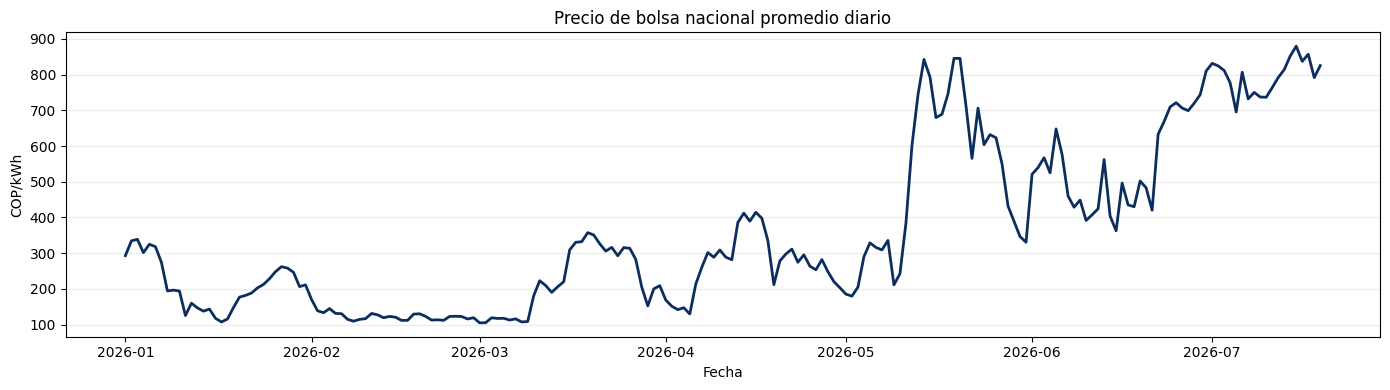

In [0]:
try:
    import matplotlib.pyplot as plt

    operacion_pdf = operacion_diaria.orderBy("fecha").toPandas()
    ax = operacion_pdf.plot(
        x="fecha",
        y=["generacion_gwh", "demanda_gwh", "disponibilidad_gwh"],
        figsize=(14, 6),
        linewidth=2,
        color=["#1473E6", "#F2B705", "#00979D"],
    )
    ax.set_title("Operación diaria del sistema")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("GWh")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    precio_nal_pdf = (
        precio_diario
        .filter(F.col("codigo_variable") == "PB_Nal")
        .orderBy("fecha")
        .toPandas()
    )
    ax = precio_nal_pdf.plot(
        x="fecha",
        y="precio_promedio_cop_kwh",
        figsize=(14, 4),
        linewidth=2,
        color="#0B2E5E",
        legend=False,
    )
    ax.set_title("Precio de bolsa nacional promedio diario")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("COP/kWh")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"No fue posible renderizar los gráficos operativos: {exc}")

## 15. Niveles de embalses: continuidad y variaciones

In [0]:
niveles_canonicos = (
    seleccionar_version_canonica("niveles_embalses")
    .withColumn("fecha", F.to_date(fecha_evento("niveles_embalses")))
    .withColumn("codigo_planta_norm", F.upper(F.trim("codigo_planta")))
    .withColumn("nivel_kwh", F.expr("try_cast(valor as double)"))
)

ventana_nivel = Window.partitionBy("codigo_planta_norm").orderBy("fecha")
niveles_variacion = (
    niveles_canonicos
    .withColumn("nivel_anterior_kwh", F.lag("nivel_kwh").over(ventana_nivel))
    .withColumn("dias_desde_anterior", F.datediff("fecha", F.lag("fecha").over(ventana_nivel)))
    .withColumn("variacion_kwh", F.col("nivel_kwh") - F.col("nivel_anterior_kwh"))
    .withColumn(
        "variacion_pct",
        F.when(
            F.abs(F.col("nivel_anterior_kwh")) > 0,
            F.col("variacion_kwh") / F.abs(F.col("nivel_anterior_kwh")) * 100
        )
    )
)

display(
    niveles_variacion
    .filter(F.col("nivel_anterior_kwh").isNotNull())
    .orderBy(F.desc(F.abs(F.col("variacion_pct"))))
    .select(
        "fecha", "codigo_planta_norm", "version",
        "nivel_anterior_kwh", "nivel_kwh",
        "dias_desde_anterior", "variacion_kwh", "variacion_pct"
    )
    .limit(100)
)

fecha,codigo_planta_norm,version,nivel_anterior_kwh,nivel_kwh,dias_desde_anterior,variacion_kwh,variacion_pct
2026-01-03,ALBG,TXF,1069532.0,4983564.0,1,3914032.0,365.9574468085106
2026-03-24,ALBG,TXF,1012642.0,3595448.0,1,2582806.0,255.05617977528087
2026-02-03,ALBG,TXF,8214916.0,2.4075848E7,1,1.5860932E7,193.07479224376732
2026-02-23,SNCR,TXF,1.0758512E7,3.1196688E7,1,2.0438176E7,189.97214484679665
2026-03-10,ALBG,TXF,7509480.0,2.1481664E7,1,1.3972184E7,186.06060606060606
2026-04-15,ALBG,TXF,3618204.0,9762324.0,1,6144120.0,169.81132075471697
2026-01-03,SNCR,TXF,1.2032152E7,3.0702216E7,1,1.8670064E7,155.1681195516812
2026-06-06,PRC3,TXR,2.8803154E7,7.1595926E7,1,4.2792772E7,148.5697434385137
2026-06-09,SNCR,TXR,1.6587288E7,3.9078272E7,1,2.2490984E7,135.59168925022584
2026-05-06,SNCR,TXF,1.3350744E7,3.1271608E7,1,1.7920864E7,134.23120089786758


## 16. Rankings descriptivos

In [0]:
top_generacion = (
    seleccionar_version_canonica("generacion_real")
    .withColumn("generacion_gwh", F.expr("try_cast(valor as double)") / F.lit(1_000_000))
    .groupBy("codigo_planta", "codigo_sic_agente")
    .agg(
        F.sum("generacion_gwh").alias("generacion_gwh"),
        F.countDistinct(F.to_date(fecha_evento("generacion_real"))).alias("dias_observados"),
    )
    .orderBy(F.desc("generacion_gwh"))
)
display(top_generacion.limit(100))

top_disponibilidad = (
    seleccionar_version_canonica("disponibilidad_plantas")
    .withColumn("disponibilidad_gwh", F.expr("try_cast(valor as double)") / F.lit(1_000_000))
    .groupBy("codigo_planta")
    .agg(
        F.sum("disponibilidad_gwh").alias("disponibilidad_gwh"),
        F.countDistinct(F.to_date(fecha_evento("disponibilidad_plantas"))).alias("dias_observados"),
    )
    .orderBy(F.desc("disponibilidad_gwh"))
)
display(top_disponibilidad.limit(100))

codigo_planta,codigo_sic_agente,generacion_gwh,dias_observados
PES1,EPMG,4971.107607090001,194
SNCR,ISGG,3294.62700874,194
SOG1,ISGG,3064.9704740599996,194
GVIO,ENDG,2847.9539704000003,194
PRC3,EPMG,1979.03682097,194
CHVR,CHVG,1930.2538948999998,194
PGUG,ENDG,1556.04575084,194
GTPE,EPMG,1504.55623201,194
TBST,TBSG,1498.85658349,194
CHBG,ENDG,1318.1361797699997,194


codigo_planta,disponibilidad_gwh,dias_observados
SNCR,5200.02316,198
GVIO,5165.6843499999995,198
PES1,5122.57839,198
CHVR,4279.99237,198
SOG1,3609.8026,198
TBST,3576.0019899999998,198
PRC3,3143.4773200000004,198
PGUG,2636.7676999999994,198
TCDT,2533.951979999999,198
GTPE,2321.5599700000002,198


## 17. Scorecard automático de candidatos a hallazgo

In [0]:
hallazgos = []

def agregar_hallazgo(tabla, dimension, hallazgo, evidencia, severidad):
    hallazgos.append({
        "tabla": tabla,
        "dimension": dimension,
        "hallazgo_candidato": hallazgo,
        "evidencia": evidencia,
        "severidad_preliminar": severidad,
    })

for r in validez_tipo_df.collect():
    if r["registros_invalidos"] and r["registros_invalidos"] > 0:
        sev = "ALTA" if (r["pct_invalido"] or 0) >= 1 else "MEDIA"
        agregar_hallazgo(
            r["tabla"], "VALIDEZ",
            f"{r['columna']} contiene valores no convertibles a {r['tipo_objetivo']}",
            f"{r['registros_invalidos']:,} registros ({r['pct_invalido']:.4f} %)",
            sev,
        )

for r in duplicados_df.collect():
    if r["filas_excedentes"] and r["filas_excedentes"] > 0:
        if r["perfil"] in {"conflicto_valor_misma_version", "id_tecnico"}:
            sev = "CRÍTICA"
        elif r["perfil"] == "llave_con_version":
            sev = "ALTA"
        else:
            sev = "MEDIA"
        agregar_hallazgo(
            r["tabla"], "UNICIDAD",
            f"Se detectó {r['perfil'].replace('_', ' ')}",
            f"{r['grupos_duplicados']:,} grupos; {r['filas_excedentes']:,} filas excedentes; máximo {r['max_repeticiones']} repeticiones",
            sev,
        )

for r in dominios_inesperados_df.collect():
    agregar_hallazgo(
        r["tabla"], "VALIDEZ",
        f"Valor no esperado en {r['columna']}: {r['valor']}",
        f"{r['registros']:,} registros; dominio esperado: {r['valores_esperados']}",
        "ALTA",
    )

for r in completitud_df.filter(F.col("pct_faltante") > 0).collect():
    if r["columna"] in AUDITORIA:
        continue
    pct = r["pct_faltante"] or 0
    sev = "ALTA" if pct >= 10 else "MEDIA" if pct >= 1 else "BAJA"
    agregar_hallazgo(
        r["tabla"], "COMPLETITUD",
        f"{r['columna']} presenta nulos o vacíos",
        f"{r['faltantes_total']:,} registros ({pct:.4f} %)",
        sev,
    )

for r in continuidad_df.collect():
    if r["grupos_incompletos"] and r["grupos_incompletos"] > 0:
        agregar_hallazgo(
            r["tabla"], "CONTINUIDAD",
            r["control"].replace("_", " "),
            f"{r['grupos_incompletos']:,} grupos o días incompletos entre {r['fecha_min']} y {r['fecha_max']}",
            "MEDIA",
        )

for r in integridad_df.collect():
    if r["codigos_huerfanos"] and r["codigos_huerfanos"] > 0:
        cobertura = r["cobertura_pct"] or 0
        sev = "ALTA" if cobertura < 95 else "MEDIA"
        agregar_hallazgo(
            r["tabla_hija"], "INTEGRIDAD",
            f"Claves sin correspondencia: {r['relacion']}",
            f"{r['codigos_huerfanos']:,} de {r['codigos_hijos']:,} códigos; cobertura {cobertura:.2f} %",
            sev,
        )

for r in perfil_numerico_df.collect():
    if r["negativos"] and r["negativos"] > 0:
        agregar_hallazgo(
            r["tabla"], "VALIDEZ",
            f"{r['columna']} contiene valores negativos",
            f"{r['negativos']:,} registros ({r['pct_negativos']:.4f} %)",
            "MEDIA",
        )

orden_severidad = F.create_map(
    F.lit("CRÍTICA"), F.lit(1),
    F.lit("ALTA"), F.lit(2),
    F.lit("MEDIA"), F.lit(3),
    F.lit("BAJA"), F.lit(4),
)

if hallazgos:
    hallazgos_df = (
        spark.createDataFrame(hallazgos)
        .withColumn("_orden", F.element_at(orden_severidad, F.col("severidad_preliminar")))
        .orderBy("_orden", "tabla", "dimension")
        .drop("_orden")
    )
    display(hallazgos_df)
else:
    hallazgos_df = spark.createDataFrame(
        [], "tabla string, dimension string, hallazgo_candidato string, "
        "evidencia string, severidad_preliminar string"
    )
    print("No se generaron candidatos automáticos.")

dimension,evidencia,hallazgo_candidato,severidad_preliminar,tabla
INTEGRIDAD,168 de 620 códigos; cobertura 72.90 %,Claves sin correspondencia: disponibilidad_plantas.codigo_planta -> plantas.codigo_planta,ALTA,disponibilidad_plantas
COMPLETITUD,13 registros (40.6250 %),latitud presenta nulos o vacíos,ALTA,embalses
COMPLETITUD,13 registros (40.6250 %),longitud presenta nulos o vacíos,ALTA,embalses
INTEGRIDAD,161 de 612 códigos; cobertura 73.69 %,Claves sin correspondencia: generacion_real.codigo_planta -> plantas.codigo_planta,ALTA,generacion_real
CONTINUIDAD,1 grupos o días incompletos entre 2026-01-01 y 2026-07-17,dias globales faltantes,MEDIA,demanda_real
UNICIDAD,"395,448 grupos; 985,896 filas excedentes; máximo 4 repeticiones",Se detectó llaves con multiples versiones,MEDIA,demanda_real
UNICIDAD,"2,535,432 grupos; 8,418,792 filas excedentes; máximo 5 repeticiones",Se detectó llaves con multiples versiones,MEDIA,disponibilidad_plantas
VALIDEZ,19 registros (59.3750 %),longitud contiene valores negativos,MEDIA,embalses
UNICIDAD,"2,523,720 grupos; 9,162,576 filas excedentes; máximo 5 repeticiones",Se detectó llaves con multiples versiones,MEDIA,generacion_real
UNICIDAD,"4,116 grupos; 14,826 filas excedentes; máximo 5 repeticiones",Se detectó llaves con multiples versiones,MEDIA,niveles_embalses


## 18. Controles de razonabilidad revisados

Los controles se reconciliaron con las salidas ejecutadas:

- **Inventario:** 9 tablas y 24.590.150 registros; no faltan tablas requeridas.
- **Esquema y validez:** todos los campos numéricos y temporales evaluados convierten correctamente; no se observaron dominios, unidades ni duraciones fuera de lo esperado.
- **Unicidad:** no existen duplicados de payload, de llave con versión, de `id` técnico ni conflictos de valor dentro de una misma versión. La multiplicidad observada corresponde a revisiones `TX`.
- **Continuidad:** todos los grupos entidad-día observados en fuentes horarias contienen 24 periodos y no hay grupos sobrecompletos. La única fecha global faltante es `2026-07-14` en demanda.
- **Comparabilidad temporal:** la comparación completa entre generación, demanda y disponibilidad se limita a 194 días, desde `2026-01-01` hasta `2026-07-13`.
- **Integridad:** los agentes tienen cobertura referencial de 100 %, pero la cobertura del maestro de plantas es solo 73,69 % para generación y 72,90 % para disponibilidad.
- **Coordenadas:** 13 pares faltantes; las 19 coordenadas disponibles pasan los controles de rango.
- **Outliers:** los límites IQR se interpretan como señal exploratoria y no como regla de rechazo, porque las medidas mezclan plantas y agentes de escalas muy distintas y contienen muchos ceros operativos.
- **Alertas automáticas reinterpretadas:** las longitudes negativas son correctas en Colombia y las múltiples versiones `TX` no son duplicados defectuosos.
- **Capacidad:** el análisis horario utilizó la capacidad más reciente de cada planta para todo el historial. Por ello, los excesos frente a capacidad son candidatos de investigación y deben reconfirmarse con una unión temporal por fecha.

## 19. Conclusiones generales

### Estado general de Bronze

La capa Bronze es **técnicamente confiable para conservar el dato crudo y alimentar transformaciones controladas**, pero es **apta con condiciones** para análisis. La mayor parte de los problemas no está en el formato ni en la ingestión: está en la resolución de versiones, la conformación de dimensiones, la sincronización temporal y algunas reglas de negocio.

| Dimensión | Evidencia observada | Evaluación |
|---|---|---|
| Estructura y tipos | 0 conversiones inválidas en fechas y medidas evaluadas | Fuerte |
| Dominios | 0 valores inesperados en duraciones, variables, unidades, mercados y versiones | Fuerte |
| Unicidad técnica | 0 duplicados exactos, de llave con versión, de `id` y 0 conflictos de valor en la misma versión | Fuerte |
| Continuidad horaria | 24 periodos en todos los grupos entidad-día observados; 0 grupos incompletos o sobrecompletos | Fuerte |
| Continuidad global | 1 día faltante en demanda: 2026-07-14 | Riesgo medio |
| Integridad planta | 161 códigos huérfanos en generación y 168 en disponibilidad | Riesgo alto |
| Integridad agente | 100 % de cobertura en demanda, generación y plantas | Fuerte |
| Geografía de embalses | 13 de 32 sin coordenadas | Riesgo alto para mapas |
| Frescura comparativa | último corte común de los tres hechos operativos: 2026-07-13 | Riesgo alto para lectura “actual” |
| Coherencia operativa | anomalías minoritarias, pero concentradas en plantas específicas | Requiere investigación |

### Principales fortalezas

1. **La ingestión no introdujo duplicación técnica.** Esto permite distinguir claramente la historia de revisiones de un error de reingesta.
2. **Los identificadores están limpios:** no tienen nulos, vacíos, espacios externos ni problemas de mayúsculas; los códigos de plantas y agentes conservan longitud de cuatro caracteres.
3. **Los dominios son estables.** Las fuentes usan las variables, unidades, duraciones y mercados esperados.
4. **La continuidad interna es alta.** Cuando una entidad aparece en un día horario, conserva sus 24 observaciones.
5. **La relación con agentes es completa.** Los códigos de agente de demanda, generación y plantas encuentran correspondencia en el maestro.

### Principales riesgos

#### 1. Las versiones `TX` deben resolverse antes de cualquier agregación

La multiplicidad entre versiones es masiva pero esperada. El dato canónico representa entre 21,80 % y 30,75 % del volumen crudo de los cinco hechos versionados. Sumar Bronze sin resolver versiones sobrestimaría los resultados aproximadamente entre 3,25 y 4,59 veces.

Además, las revisiones no son siempre cosméticas:

- Demanda: cambio p95 de 0,3200 % y rango máximo de 1.047.744,88 kWh.
- Precio: cambio mediano de 1,0375 %, p95 de 8,5109 % y rango máximo de 774,851 COP/kWh.
- Generación y disponibilidad: p95 igual a cero, pero con casos aislados de hasta 212.593,99 kWh y 376.000 kWh.
- Niveles de embalses: las versiones observadas mantienen el mismo valor para cada llave.

Por tanto, Silver debe conservar trazabilidad de la versión recibida y publicar una sola fila vigente por llave canónica.

#### 2. El maestro de plantas no conforma por sí solo todos los recursos operativos

La cobertura por código es 73,69 % en generación y 72,90 % en disponibilidad. Esto no parece un problema de formato porque los códigos son válidos y normalizados; apunta a una diferencia de alcance entre el maestro y los hechos, recursos retirados/nuevos, interconexiones o códigos que requieren otra tabla de referencia.

Hasta resolverlo, ningún hecho debe unirse a `plantas` mediante `INNER JOIN`. Se necesita una dimensión conformada que preserve todos los códigos y marque explícitamente los no clasificados.

#### 3. Las fuentes tienen cortes diferentes

Al 23 de julio de 2026:

| Fuente | Última fecha del evento | Rezago frente al 23-jul |
|---|---:|---:|
| Agentes | 2026-07-22 | 1 día |
| Plantas | 2026-07-22 | 1 día |
| Precio de bolsa | 2026-07-19 | 4 días |
| Niveles de embalses | 2026-07-19 | 4 días |
| Demanda real | 2026-07-17 | 6 días |
| Disponibilidad | 2026-07-17 | 6 días |
| Generación real | 2026-07-13 | 10 días |

Esto no prueba por sí solo una falla de carga, porque SIMEM publica fuentes con latencias distintas. Sí implica que cualquier visual combinado debe mostrar su fecha de corte y trabajar con la mínima fecha máxima común.

#### 4. Existen señales operativas concentradas, no un problema generalizado

En 2.550.480 combinaciones planta-hora comparables:

- 13.176 horas (0,5166 %) presentan generación superior a disponibilidad por más de 5 %.
- 2.873 horas (0,1126 %) tienen disponibilidad cero con generación positiva.
- La mediana del cociente generación/disponibilidad es 1,0000 y el p95 es 1,000097; las excepciones se concentran en pocas plantas.

Frente a la capacidad más reciente del maestro, 33.094 de 2.000.424 horas (1,6543 %) superan la capacidad por más de 5 %. `TYP1` domina los valores extremos visibles, con un factor máximo de 2,3775. Este resultado debe reconfirmarse usando la capacidad vigente en la fecha del evento; todavía no debe clasificarse como error confirmado.

### Lectura descriptiva del sistema

En los 194 días comparables entre `2026-01-01` y `2026-07-13`:

- Generación media: **240,74 GWh/día**.
- Demanda media: **234,90 GWh/día**.
- Disponibilidad media: **404,47 GWh/día**.
- Diferencia media generación–demanda: **5,83 GWh/día**, equivalente al 2,48 % de la demanda media.
- Utilización media de disponibilidad: **59,72 %**, con rango diario entre 48,00 % y 69,88 %.

La generación agregada supera a la demanda agregada en los 194 días. No debe interpretarse automáticamente como “excedente”: antes hay que confirmar que ambas fuentes tengan el mismo alcance e incluir pérdidas, exportaciones, autoconsumo y demás componentes del balance.

### Implicaciones para Silver y Gold

- **Silver:** resolver versiones, tipar columnas, conservar auditoría, implementar dimensiones conformadas y aplicar uniones temporales.
- **Gold:** consumir solo filas canónicas, usar fecha de corte común y mantener miembros `DESCONOCIDO/NO CLASIFICADO` para no perder hechos.
- **Dashboard:** mostrar fecha de actualización por fuente; los KPI combinados deben quedar vacíos fuera de la ventana común, no completar con cero.
- **Modelado histórico:** tratar `agentes` y `plantas` como snapshots susceptibles de cambios de nombre, atributos y capacidad.

## 20. Conclusiones por fuente

### Agentes

- Contiene **73.570 registros**, con cobertura de eventos desde `2026-01-01` hasta `2026-07-22`.
- No presenta nulos, dominios inesperados, duplicados ni problemas de formato en `codigo_sic_agente`.
- Las cuatro actividades observadas son Comercializador (42,999 % de las filas), Generador (42,357 %), Distribuidor (10,506 %) y Transportador (4,139 %).
- Cinco códigos muestran más de un nombre normalizado: `NESC`, `BTGC`, `SOEG`, `SOEC` y `TEMG`. En algunos casos hay cambio societario; en `TEMG` parece una variación de puntuación.
- **Conclusión:** fuente apta como dimensión histórica, pero no conviene sobrescribir el nombre. Se requiere SCD tipo 2 o, como mínimo, vigencia por fecha y tabla de alias.

### Demanda real

- Contiene **1.423.752 filas crudas** y **437.856 llaves canónicas**.
- Cubre `2026-01-01` a `2026-07-17`; falta globalmente **2026-07-14**. Fuera de ese día, todos los grupos observados tienen 24 horas.
- Solo aparecen `TX2`, `TX3`, `TXR` y `TXF`; la ausencia de `TX1` es propia de esta extracción y no genera valores fuera del dominio permitido.
- No hay negativos ni conversiones inválidas; 23.004 filas crudas son cero (1,6157 %).
- Las revisiones son generalmente pequeñas, pero existen cambios extremos en `BEIC` y `CSIC`; el rango máximo alcanza 1.047.744,88 kWh.
- En los 197 días con demanda, el mercado Regulado representa **69,05 %** y el No Regulado **30,95 %** de la energía agregada.
- **Conclusión:** apta después de seleccionar versión canónica. Debe investigarse o documentarse el faltante del 14 de julio y monitorear las revisiones grandes por agente.

### Disponibilidad de plantas

- Contiene **11.028.576 filas crudas** y **2.609.784 llaves canónicas**.
- Cubre sin días globales faltantes desde `2026-01-01` hasta `2026-07-17`; todos los grupos entidad-día observados tienen 24 horas.
- Los valores convierten correctamente y no hay negativos. Los ceros representan 42,7899 % del histórico crudo; por el tipo de variable, son estados operativos posibles y no deben rechazarse sin contexto.
- Hay **168 códigos huérfanos de 620 (27,10 %)** frente al maestro de plantas.
- Las revisiones suelen conservar el valor (p95 de cambio igual a cero), aunque existen casos puntuales de hasta 376.000 kWh.
- **Conclusión:** temporalmente sólida, pero condicionada por la integridad con plantas. Gold debe preservar recursos no clasificados y no perderlos en la unión.

### Embalses

- El maestro contiene **32 embalses**, sin duplicados ni problemas en los códigos.
- Faltan latitud y longitud en **13 embalses (40,625 %)**: `SALVAJIN`, `PUNCHINA`, `MIEL1`, `SNRAFAEL`, `ELQUIMBO`, `CALIMA1`, `QUBRADON`, `MUNA`, `PENOL`, `MIRAFLOR`, `URRA1`, `NEUSA` y `TOMINE`.
- Las 19 coordenadas presentes convierten correctamente, cumplen rangos geográficos y están dentro de la caja aproximada de Colombia.
- Las longitudes negativas son correctas para Colombia y no constituyen una anomalía.
- **Conclusión:** apta para identificación, no apta todavía para cobertura geográfica completa. La geocodificación debe resolverse antes de publicar mapas o cálculos espaciales.

### Generación real

- Contiene **11.716.152 filas crudas** y **2.553.576 llaves canónicas**.
- Cubre de forma continua `2026-01-01` a `2026-07-13`; todos los grupos observados tienen 24 horas.
- No hay negativos ni conversiones inválidas. Los ceros representan 46,9147 % del histórico crudo y son compatibles con horas sin generación.
- La cobertura de agentes es 100 %, pero **161 de 612 códigos de planta (26,31 %)** no aparecen en el maestro.
- El 99,8788 % de las llaves canónicas planta-hora encuentra disponibilidad comparable.
- Las anomalías generación/disponibilidad se concentran principalmente en `PSUA`, `ESMR`, `HMIN`, `CUC1`, `TYP1`, `MOY1` y `CLL1`. `PSUA` registra 1.435 horas con disponibilidad cero y generación positiva.
- Las plantas con mayor generación acumulada en el periodo son `PES1` (4.971,11 GWh), `SNCR` (3.294,63 GWh), `SOG1` (3.064,97 GWh) y `GVIO` (2.847,95 GWh).
- **Conclusión:** fuente fuerte en continuidad y formato, pero condicionada por su fecha de corte, los códigos sin maestro y anomalías focalizadas que requieren trazabilidad por planta y versión.

### Niveles de embalses

- Contiene **19.026 filas crudas** y **4.200 llaves canónicas**, equivalentes a 21 códigos por 200 días.
- Cubre sin días faltantes desde `2026-01-01` hasta `2026-07-19`; los 21 códigos tienen correspondencia en plantas.
- Las cinco versiones disponibles repiten el mismo valor por llave: el rango de revisión es cero.
- Hay cinco ceros en las filas crudas, correspondientes a la repetición multiversión de un evento canónico; el caso visible es `ALBG` el `2026-02-01`.
- Las mayores variaciones porcentuales diarias se concentran en bases pequeñas de `ALBG` y `SNCR`; por ello deben evaluarse junto con la variación absoluta y no solo con el porcentaje.
- **Conclusión:** fuente completa y estable. Conviene validar el cero canónico y usar umbrales por embalse o por escala, no un único umbral porcentual global.

### Plantas

- Contiene **268.107 snapshots** desde `2026-01-01` hasta `2026-07-22`.
- No presenta nulos ni valores no convertibles. Existen 406 filas con capacidad efectiva neta igual a cero (0,1514 %), que deben excluirse del denominador del factor de capacidad y clasificarse según su estado operativo.
- En el histórico de snapshots, Solar representa 81,724 % de las filas, No Despachado Centralmente 93,785 % y Autogenerador de Pequeña Escala 69,641 %. Estos porcentajes describen filas históricas, no necesariamente el inventario vigente en una fecha específica.
- Cinco códigos cambian de nombre normalizado: `ARG1`, `2S6Q`, `5FPL`, `5GFB` y `5QTJ`. Algunos cambios parecen reasignaciones reales de código, no simples variaciones ortográficas.
- **Conclusión:** debe modelarse como dimensión histórica por vigencia. Para cálculos de capacidad se requiere una unión `as-of` por planta y fecha, no el último snapshot aplicado a todo el pasado.

### Relaciones planta–reservorio

- Contiene **23 relaciones**, sin nulos ni duplicados.
- Una de 20 plantas normalizadas no hace `match` exacto: `SOGAMOSOS`.
- Cinco de 23 nombres de reservorio no hacen `match` exacto: `TOPOROCO`, `PORCE III`, `URRA1`, `PORCE II` y `CALIMA 1`.
- **Conclusión:** la relación es pequeña y controlable, pero necesita un crosswalk explícito. No conviene resolver estas diferencias con coincidencia difusa durante cada carga.

### Precio de bolsa

- Contiene **60.912 filas crudas** y **14.400 llaves canónicas**, exactamente 3 variables × 24 horas × 200 días.
- Cubre de forma continua `2026-01-01` a `2026-07-19`; todos los días y variables tienen 24 horas.
- No hay nulos, ceros, negativos, conversiones inválidas ni dominios inesperados. El rango crudo observado es 88,19 a 1.581,038 COP/kWh.
- Es la fuente con revisiones relativas más materiales: cambio mediano de 1,0375 %, p95 de 8,5109 % y rango máximo de 774,851 COP/kWh.
- En los 133 días comparables visibles en la salida diaria, `PB_Int` y `PB_Tie` tienen exactamente el mismo promedio, mínimo y máximo diario. Debe confirmarse si esta igualdad responde a la definición de SIMEM antes de tratarlas como variables redundantes.
- **Conclusión:** fuente de alta calidad estructural; la selección de versión es indispensable para evitar publicar precios provisionales como definitivos.

## 21. Recomendaciones y pruebas automatizables

### Plan de acción priorizado

| Prioridad | Acción | Motivo y resultado esperado |
|---|---|---|
| P0 | Publicar una sola fila canónica por llave con prioridad `TXF > TXR > TX3 > TX2 > TX1` y desempate por ingestión | Evita multiplicar medidas y conserva el valor más definitivo disponible |
| P0 | Construir una dimensión conformada de plantas a partir del maestro y la unión de códigos observados en los hechos | Impide perder 161 códigos de generación y 168 de disponibilidad |
| P0 | Sustituir uniones internas por `LEFT JOIN` y miembro `DESCONOCIDO/NO CLASIFICADO` mientras se resuelven los códigos | Preserva el grano y el volumen de los hechos |
| P0 | Unir capacidad y atributos de planta por vigencia de fecha (`as-of`) | Revalida correctamente los 33.094 excesos frente a capacidad |
| P0 | Calcular y exponer una fecha de corte común por producto analítico | Evita comparar generación ausente con demanda o disponibilidad más recientes |
| P1 | Investigar la ausencia de demanda del `2026-07-14` y el corte de generación en `2026-07-13` | Distingue latencia esperada, hueco de extracción o publicación incompleta |
| P1 | Completar las 13 coordenadas de embalses con fuente y fecha de enriquecimiento | Habilita mapas con cobertura total y trazabilidad |
| P1 | Crear crosswalk controlado para planta–reservorio y nombres históricos | Resuelve 1 planta y 5 reservorios sin coincidencia exacta |
| P1 | Crear una tabla de anomalías operativas por planta, hora, versión y regla | Permite revisar los casos sin contaminar el hecho principal |
| P2 | Modelar agentes y plantas como SCD tipo 2 | Conserva cambios societarios, reasignaciones, capacidad y clasificación |
| P2 | Confirmar con la documentación de SIMEM la igualdad `PB_Int = PB_Tie` y el significado de los ceros NEM | Evita deduplicar o corregir valores legítimos |

### Pruebas automatizables recomendadas

| Control | Regla propuesta | Aplicación |
|---|---|---|
| Llaves obligatorias | 0 nulos o vacíos en fechas, códigos, variable, duración y versión | Todas las tablas según su grano |
| Conversión | 100 % de éxito en `try_cast` de fecha, valor, capacidad y coordenadas no nulas | Bronze → Silver |
| Unicidad | 0 filas excedentes en la llave **incluyendo versión** | Hechos versionados |
| Conflicto | 1 valor como máximo por llave y versión | Hechos versionados |
| Dominio | Solo variables, unidades, duraciones, mercados y versiones permitidas | Todas las fuentes |
| Canonización | Exactamente 1 fila por llave canónica después del ranking de versión | Silver |
| Cobertura horaria | 24 horas por entidad-día; excepciones en tabla controlada | Demanda, generación, disponibilidad y precio |
| Continuidad diaria | 0 fechas globales faltantes dentro del rango publicado | Todos los hechos; investigar el 14-jul en demanda |
| Frescura | Umbral específico por fuente, acordado con la latencia oficial | Jobs y dashboard |
| Integridad agente | Cobertura de 100 % o miembro desconocido explícito | Demanda, generación y plantas |
| Integridad planta | No permitir pérdida de filas; medir cobertura y reducir huérfanos desde la línea base | Generación, disponibilidad y niveles |
| Coordenadas | 100 % de pares completos y dentro de Colombia; fuente de geocodificación registrada | Embalses |
| Capacidad | Capacidad positiva para calcular factor; unión vigente por fecha | Generación |
| Anomalía operativa | Monitorear generación > disponibilidad × 1,05 y generación > capacidad × 1,05 | Gold de calidad |
| Revisión TX | Monitorear p95 y máximo de cambio por fuente y periodo | Todos los hechos versionados |

### Severidad final de los hallazgos

| Hallazgo | Severidad | Confianza | Impacto principal |
|---|---|---|---|
| Códigos de planta sin maestro | Alta | Alta | Pérdida de hechos y KPI sesgados en joins |
| Coordenadas faltantes en 13 embalses | Alta para geografía | Alta | Mapas y análisis espaciales incompletos |
| Cortes temporales desalineados | Alta para dashboard operativo | Alta | Comparaciones parciales o engañosas |
| Día faltante de demanda 2026-07-14 | Media | Alta | Hueco diario y series discontinuas |
| Revisiones TX materiales | Alta como requisito de transformación, no como defecto | Alta | Doble conteo o publicación de valores provisionales |
| Generación superior a disponibilidad | Media | Alta en detección, media en causa | Alertas focalizadas por planta |
| Generación superior a capacidad | Media provisional | Media | Requiere unión temporal antes de confirmar |
| Cambios de nombre por código | Media | Alta | Historia dimensional y etiquetas inconsistentes |
| Nombres planta–reservorio sin match | Media | Alta | Relaciones incompletas sin crosswalk |

### Reglas que deben documentarse, no bloquear la carga

- Longitudes negativas de Colombia.
- Varias versiones `TX` de una misma llave canónica.
- Ceros en generación y disponibilidad cuando representan estados operativos válidos.
- Outliers IQR en medidas heterogéneas; primero deben segmentarse por planta, agente, tecnología y versión.
- Diferencias entre generación y demanda hasta confirmar el alcance exacto del balance energético.

### Preguntas abiertas para cerrar con la fuente

1. ¿Los códigos de planta huérfanos corresponden a recursos retirados, generación distribuida, interconexiones u otra taxonomía de SIMEM?
2. ¿Cuál es la latencia oficial esperada para generación, disponibilidad, demanda, precio y NEM?
3. ¿La capacidad efectiva neta debe aplicarse por fecha del snapshot y está expresada en kW para todos los recursos?
4. ¿La igualdad observada entre `PB_Int` y `PB_Tie` es una regla de negocio o una redundancia de la fuente?
5. ¿El cero de `ALBG` el `2026-02-01` representa un nivel válido o un valor centinela?

### Dictamen

**Bronze queda aprobada como capa de conservación y trazabilidad. Silver queda aprobada de forma condicionada a las acciones P0. Gold y el dashboard deben consumir exclusivamente datos canónicos, temporalmente alineados y con dimensiones conformadas.**